# Q-factorisation on Gridworld Maze - Combined loss

In [13]:
from pathlib import Path
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import time
from copy import deepcopy


# Resolve repository src path robustly when running notebook in-place.
repo_root = Path.cwd()
while repo_root != repo_root.parent and not (repo_root / 'src').exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root / 'src'))

from environments.maze_discrete import MazeGridWorld, MazeGoalWrapper
from utils import set_seed, estimate_fisher_diag, compute_embedding_drift, collect_weight_snapshot, sample_goals, get_free_cells, evaluate_policy
from visualisations import visualise_embeddings, visualise_q_table, print_goal_embedding_similarity, plot_full_embedding_dashboard_2d_html, plot_min_steps_and_min_time
from networks import snapshot_named_parameters, FactorisedDQN_QNetwork
from trainer import dqn_train_multi_loss


DEVICE = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
print('Using device:', DEVICE)


Using device: mps


In [14]:
MAZE_LAYOUT = [
    [1,1,1,1,1,1,1,1,1,1,1],
    [1,0,0,0,0,1,0,0,0,0,1],
    [1,0,1,1,0,1,0,1,1,0,1],
    [1,0,1,0,0,0,0,0,1,0,1],
    [1,0,1,0,1,1,1,0,1,0,1],
    [1,0,0,0,1,0,0,0,1,0,1],
    [1,1,1,0,1,0,1,1,1,0,1],
    [1,0,0,0,0,0,1,0,0,0,1],
    [1,0,1,1,1,0,1,1,1,0,1],
    [1,0,0,0,1,0,0,0,0,0,1],
    [1,1,1,1,1,1,1,1,1,1,1],
]

def make_env(goal=(9, 9), slip_prob=0.00, max_horizon=100):
    base = MazeGridWorld(
        maze=MAZE_LAYOUT,
        max_episode_steps=max_horizon,
    )
    env = MazeGoalWrapper(
        base,
        goal_position=goal,
        goal_reward=1.0,
        step_reward=0.0,
        slip_prob=slip_prob,
        reward_mode="simple",
    )
    return env

## Training Loop across goals and seeds


================ SEED 42 ================

Sampled GOALS for seed 42: [(4, 1), (6, 1), (5, 5), (7, 7), (4, 2), (5, 7), (9, 8), (7, 9), (7, 3), (4, 7), (9, 3), (3, 5), (3, 6), (5, 6), (5, 9)]

----- seed=42, task_idx=0, goal=(4, 1) -----

[DQN-factorised] step=   1000 | eps=0.981 | eval_return=-8.500 | eval_len=87.6 | TD=0.000000 | ReplayTD=0.000000 | Ortho=0.000000 | SigReg=0.000000 | EWC=0.000000 | Loss=0.000000| goal_reg_loss=0.000000
[DQN-factorised] step=   2000 | eps=0.962 | eval_return=-8.537 | eval_len=87.6 | TD=0.000000 | ReplayTD=0.000000 | Ortho=0.000000 | SigReg=0.000000 | EWC=0.000000 | Loss=0.000000| goal_reg_loss=0.000000
[DQN-factorised] step=   3000 | eps=0.943 | eval_return=-9.862 | eval_len=100.0 | TD=0.000000 | ReplayTD=0.000000 | Ortho=0.000000 | SigReg=0.000000 | EWC=0.000000 | Loss=0.000000| goal_reg_loss=0.000000
[DQN-factorised] step=   4000 | eps=0.924 | eval_return=-8.525 | eval_len=87.6 | TD=0.000000 | ReplayTD=0.000000 | Ortho=0.000000 | SigReg=0.000000 | E

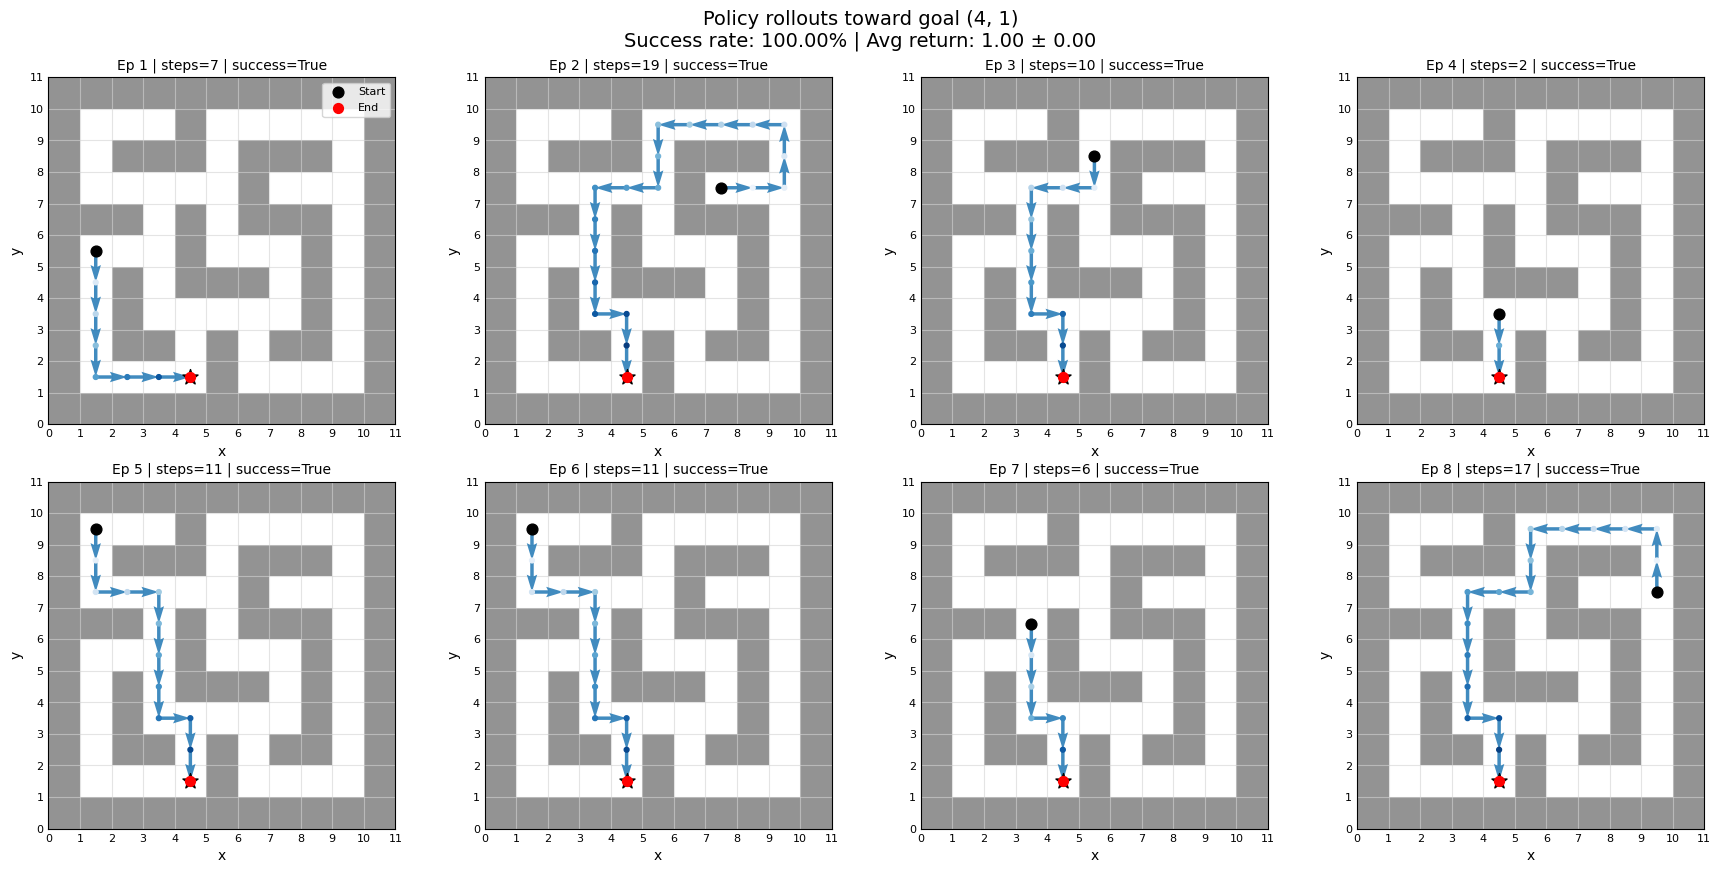

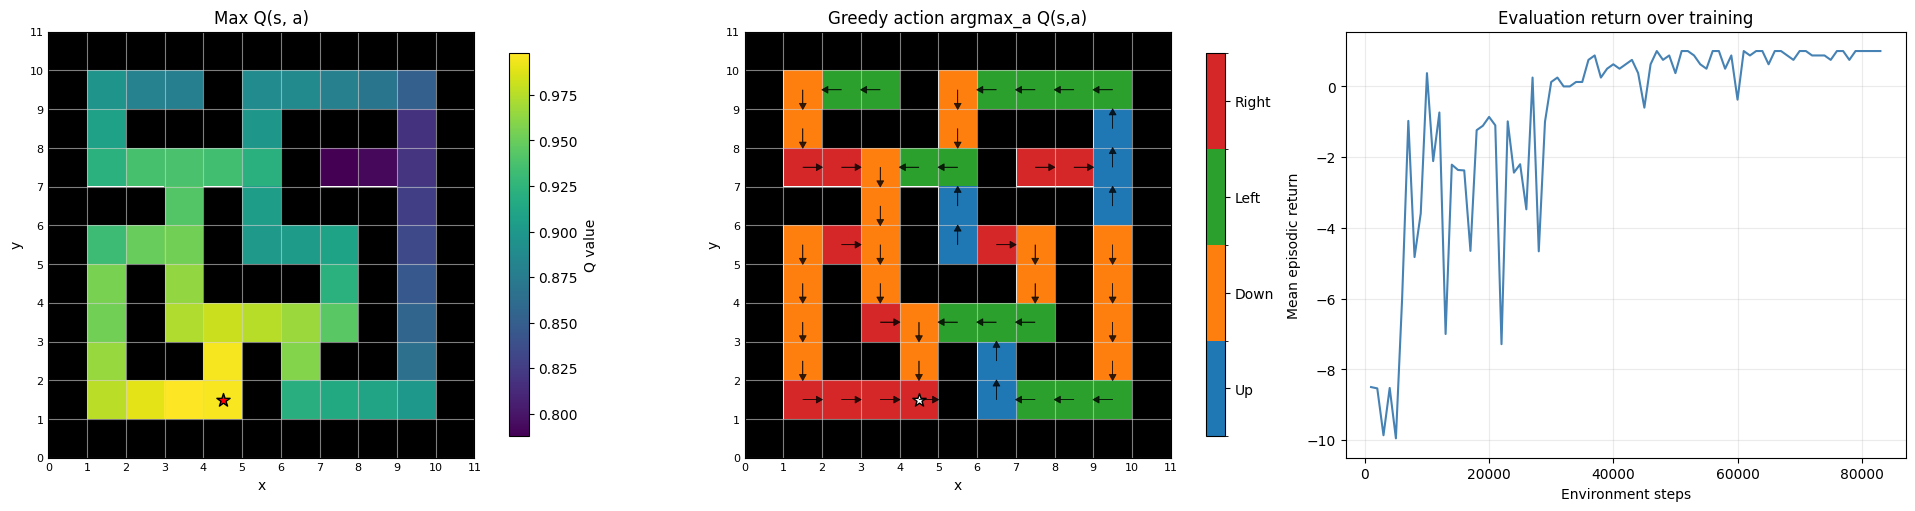

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 16)
psi(z) / task code base: (1, 16)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [3.8208628 3.2843542 2.5482066 2.3065958 2.0767758]
cumulative variance (first 5 dims): [0.28066397 0.48804247 0.61287653 0.7151603  0.7980772 ]
cos(phi(s,a), psi/task): mean=0.8555, std=0.0730


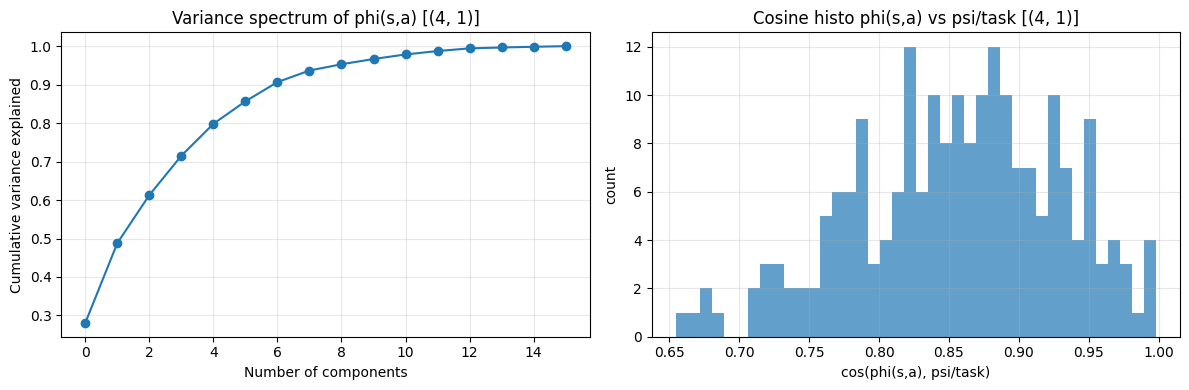


Goal embedding cosine similarity matrix:
     task_0
  task_0      1.000

----- seed=42, task_idx=1, goal=(6, 1) -----

[DQN-factorised] step=   1000 | eps=0.981 | eval_return=-7.962 | eval_len=87.8 | TD=0.000000 | ReplayTD=0.000000 | Ortho=0.000000 | SigReg=0.000000 | EWC=0.000000 | Loss=0.000000| goal_reg_loss=0.000000
[DQN-factorised] step=   2000 | eps=0.962 | eval_return=-7.987 | eval_len=88.0 | TD=0.000000 | ReplayTD=0.000000 | Ortho=0.000000 | SigReg=0.000000 | EWC=0.000000 | Loss=0.000000| goal_reg_loss=0.000000
[DQN-factorised] step=   3000 | eps=0.943 | eval_return=-6.712 | eval_len=76.1 | TD=0.000000 | ReplayTD=0.000000 | Ortho=0.000000 | SigReg=0.000000 | EWC=0.000000 | Loss=0.000000| goal_reg_loss=0.000000
[DQN-factorised] step=   4000 | eps=0.924 | eval_return=-4.112 | eval_len=52.9 | TD=0.000000 | ReplayTD=0.000000 | Ortho=0.000000 | SigReg=0.000000 | EWC=0.000000 | Loss=0.000000| goal_reg_loss=0.000000
[DQN-factorised] step=   5000 | eps=0.905 | eval_return=-6.825 | ev

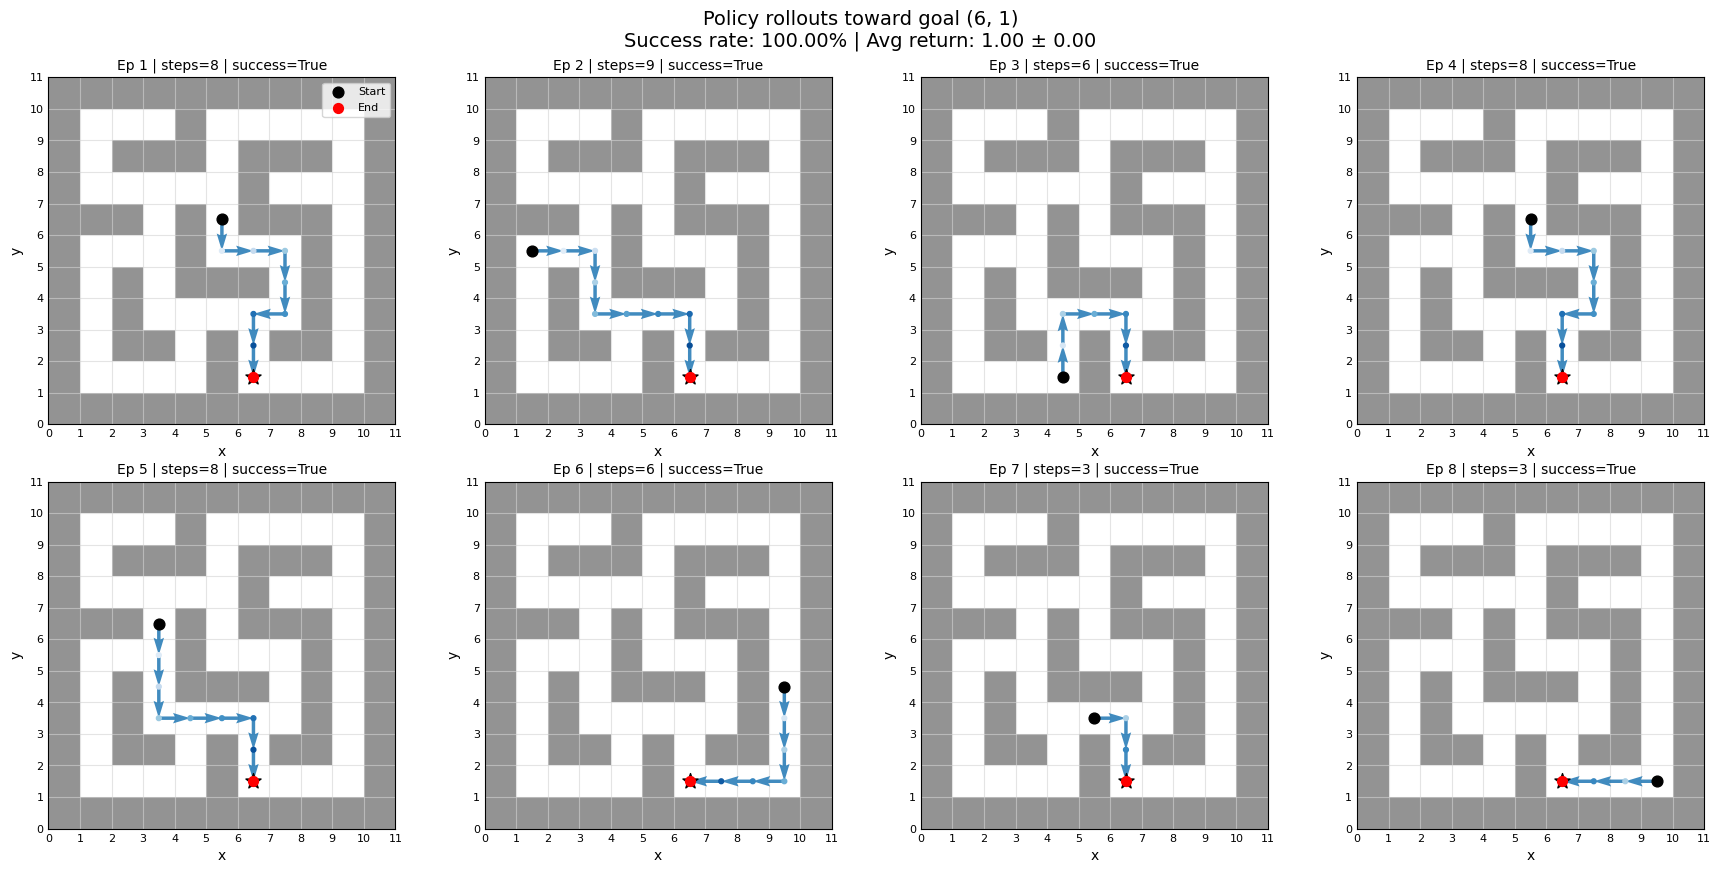

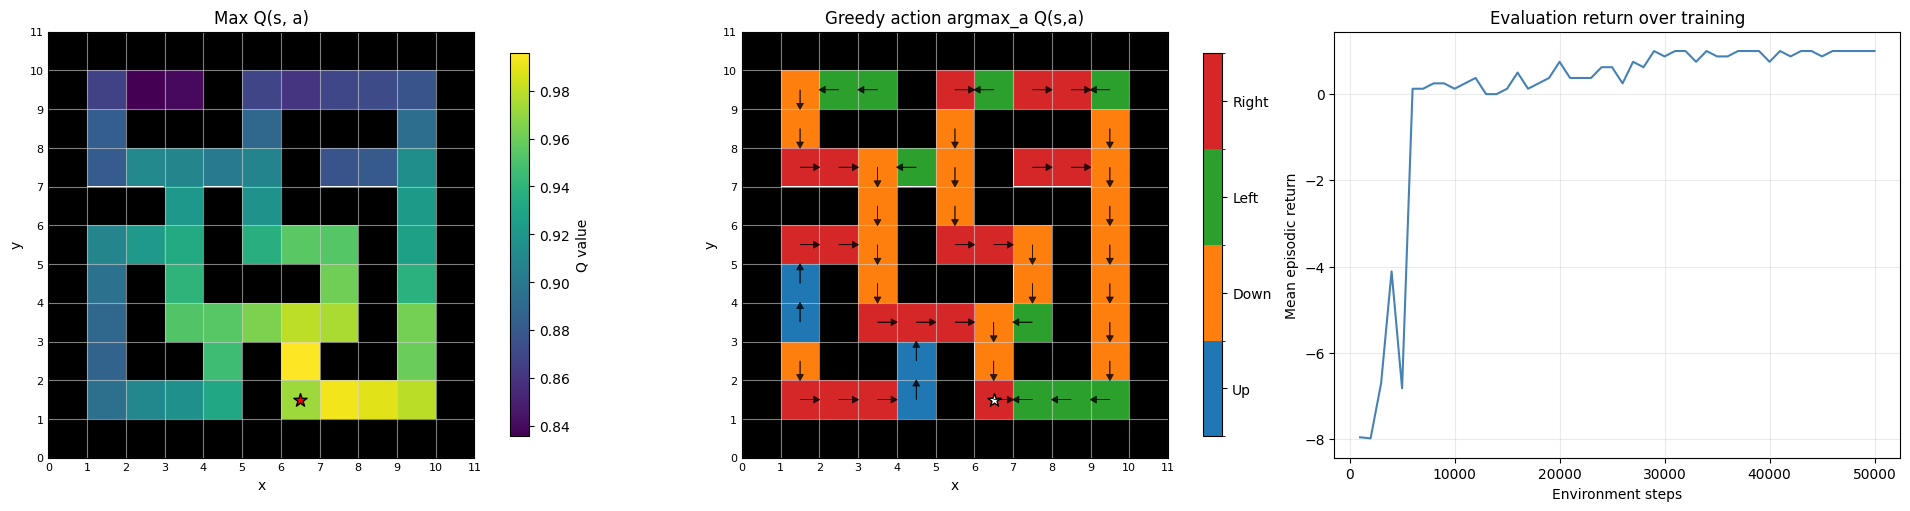

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 16)
psi(z) / task code base: (1, 16)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [3.2652395 2.977162  2.6904612 2.2958379 2.0320938]
cumulative variance (first 5 dims): [0.22594525 0.41378093 0.56718135 0.67888194 0.7663925 ]
cos(phi(s,a), psi/task): mean=0.8643, std=0.0640


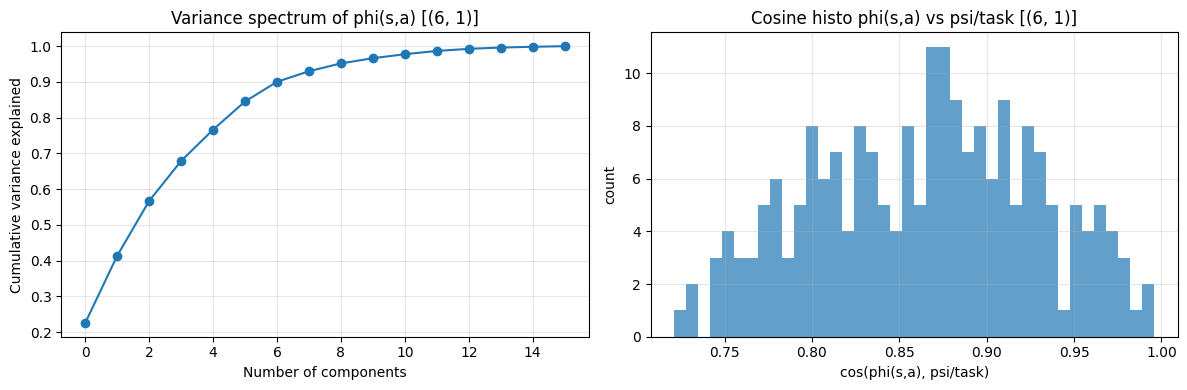


Goal embedding cosine similarity matrix:
     task_0     task_1
  task_0      1.000      0.954
  task_1      0.954      1.000

Off-diagonal mean similarity: 0.954
Off-diagonal min similarity: 0.954
Off-diagonal max similarity: 0.954

----- seed=42, task_idx=2, goal=(5, 5) -----

[DQN-factorised] step=   1000 | eps=0.981 | eval_return=0.000 | eval_len=100.0 | TD=0.000000 | ReplayTD=0.000000 | Ortho=0.000000 | SigReg=0.000000 | EWC=0.000000 | Loss=0.000000| goal_reg_loss=0.000000
[DQN-factorised] step=   2000 | eps=0.962 | eval_return=0.125 | eval_len=87.6 | TD=0.000000 | ReplayTD=0.000000 | Ortho=0.000000 | SigReg=0.000000 | EWC=0.000000 | Loss=0.000000| goal_reg_loss=0.000000
[DQN-factorised] step=   3000 | eps=0.943 | eval_return=0.000 | eval_len=100.0 | TD=0.000000 | ReplayTD=0.000000 | Ortho=0.000000 | SigReg=0.000000 | EWC=0.000000 | Loss=0.000000| goal_reg_loss=0.000000
[DQN-factorised] step=   4000 | eps=0.924 | eval_return=0.000 | eval_len=100.0 | TD=0.000000 | ReplayTD=0.00000

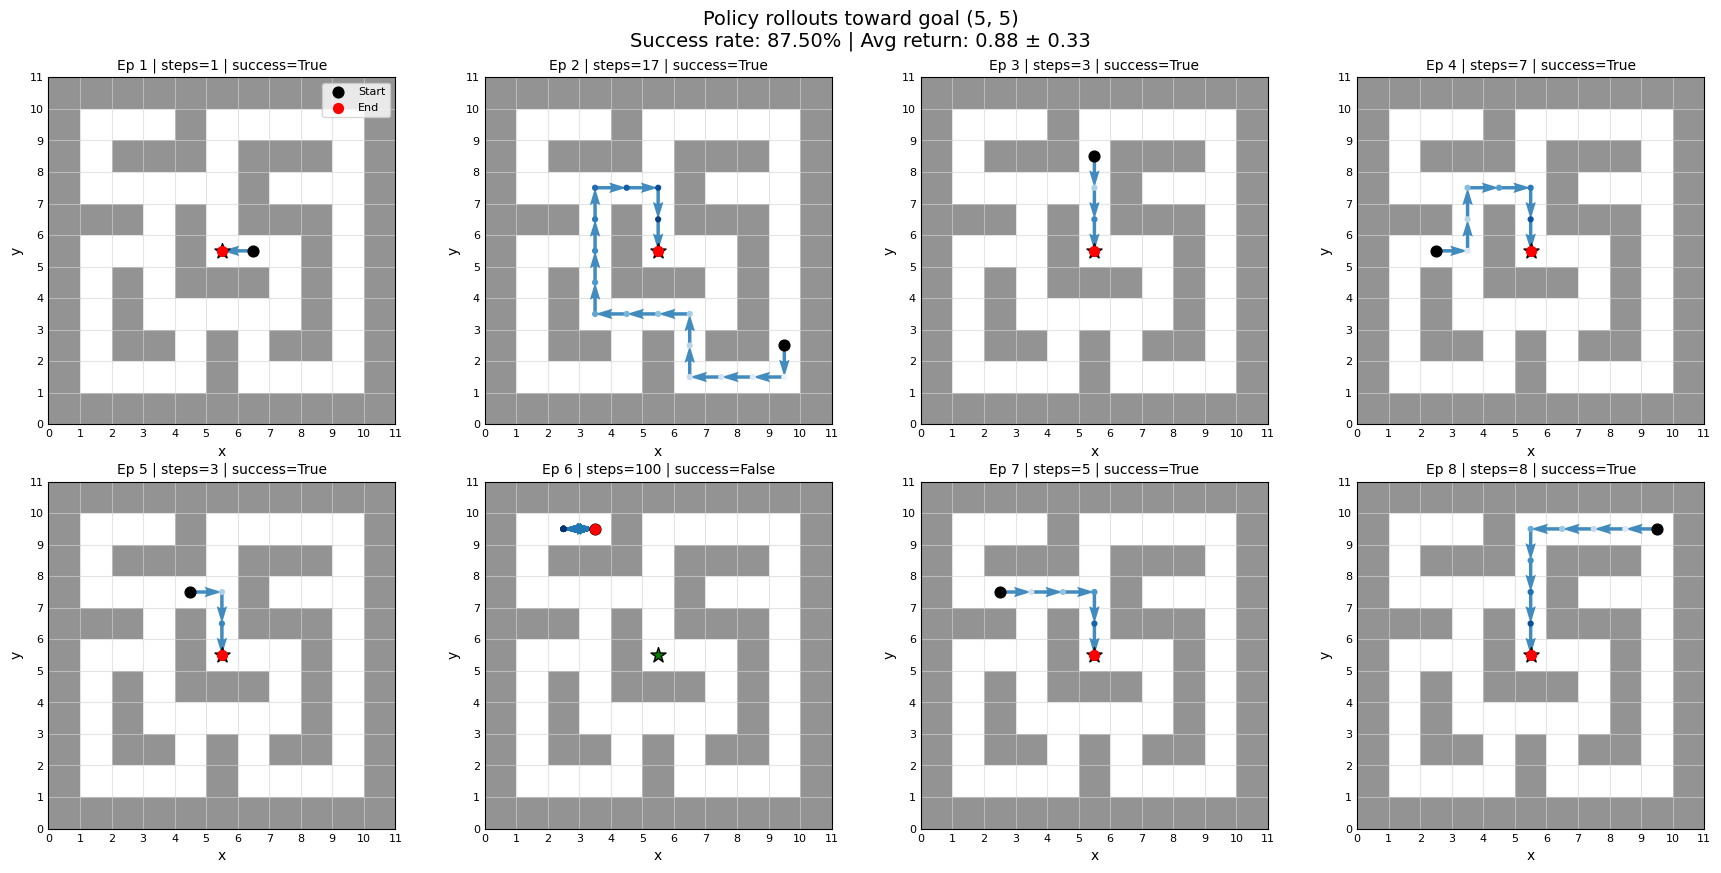

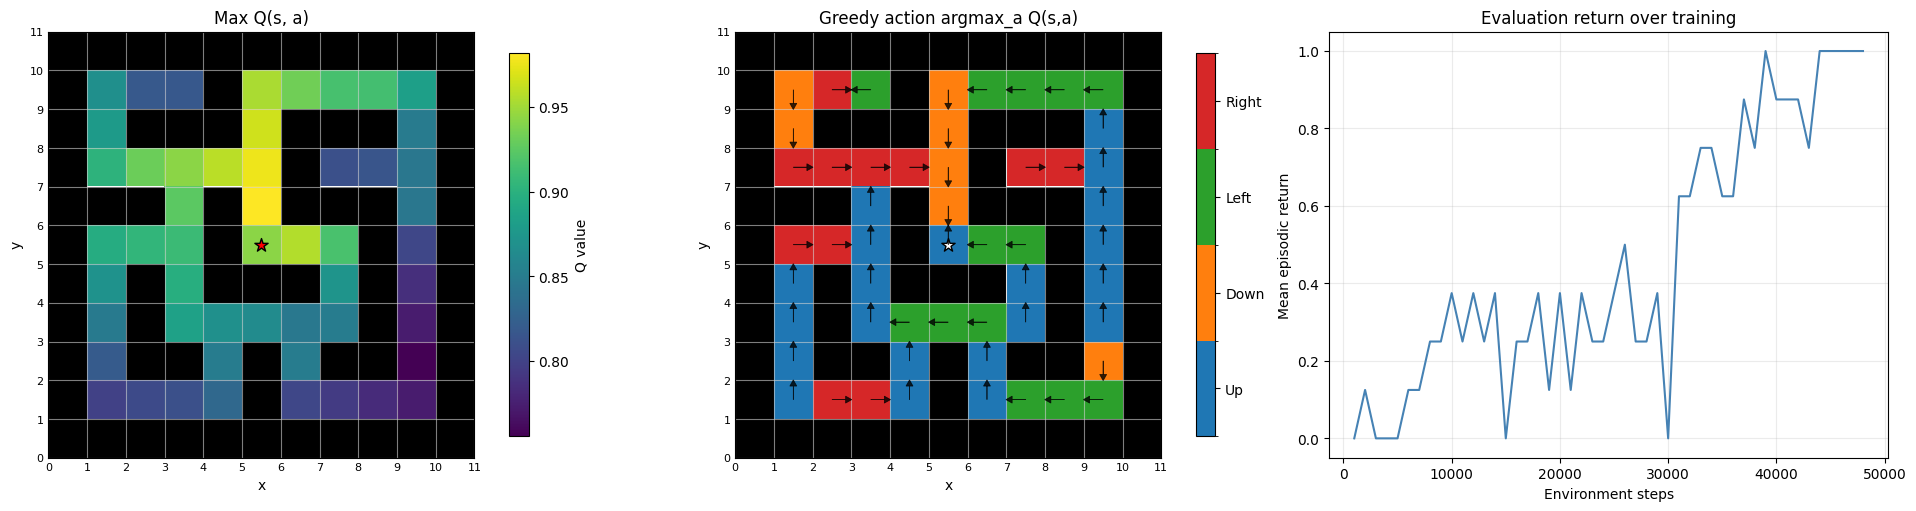

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 16)
psi(z) / task code base: (1, 16)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [3.5150845 3.1050012 2.5499525 2.2875936 2.0196152]
cumulative variance (first 5 dims): [0.24074164 0.42858818 0.55527866 0.65724045 0.73671293]
cos(phi(s,a), psi/task): mean=0.8069, std=0.0757


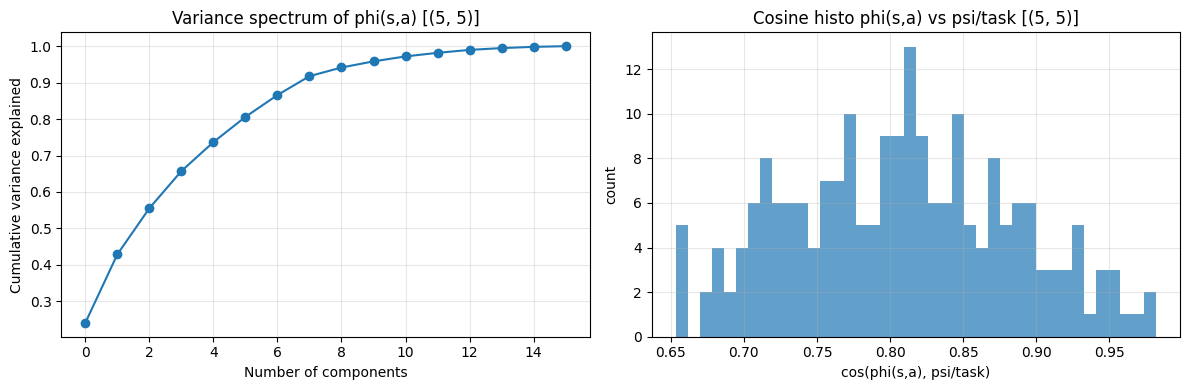


Goal embedding cosine similarity matrix:
     task_0     task_1     task_2
  task_0      1.000      0.954      0.911
  task_1      0.954      1.000      0.890
  task_2      0.911      0.890      1.000

Off-diagonal mean similarity: 0.918
Off-diagonal min similarity: 0.890
Off-diagonal max similarity: 0.954

----- seed=42, task_idx=3, goal=(7, 7) -----

[DQN-factorised] step=   1000 | eps=0.981 | eval_return=0.000 | eval_len=100.0 | TD=0.000000 | ReplayTD=0.000000 | Ortho=0.000000 | SigReg=0.000000 | EWC=0.000000 | Loss=0.000000| goal_reg_loss=0.000000
[DQN-factorised] step=   2000 | eps=0.962 | eval_return=0.000 | eval_len=100.0 | TD=0.000000 | ReplayTD=0.000000 | Ortho=0.000000 | SigReg=0.000000 | EWC=0.000000 | Loss=0.000000| goal_reg_loss=0.000000
[DQN-factorised] step=   3000 | eps=0.943 | eval_return=0.000 | eval_len=100.0 | TD=0.000000 | ReplayTD=0.000000 | Ortho=0.000000 | SigReg=0.000000 | EWC=0.000000 | Loss=0.000000| goal_reg_loss=0.000000
[DQN-factorised] step=   4000 | eps

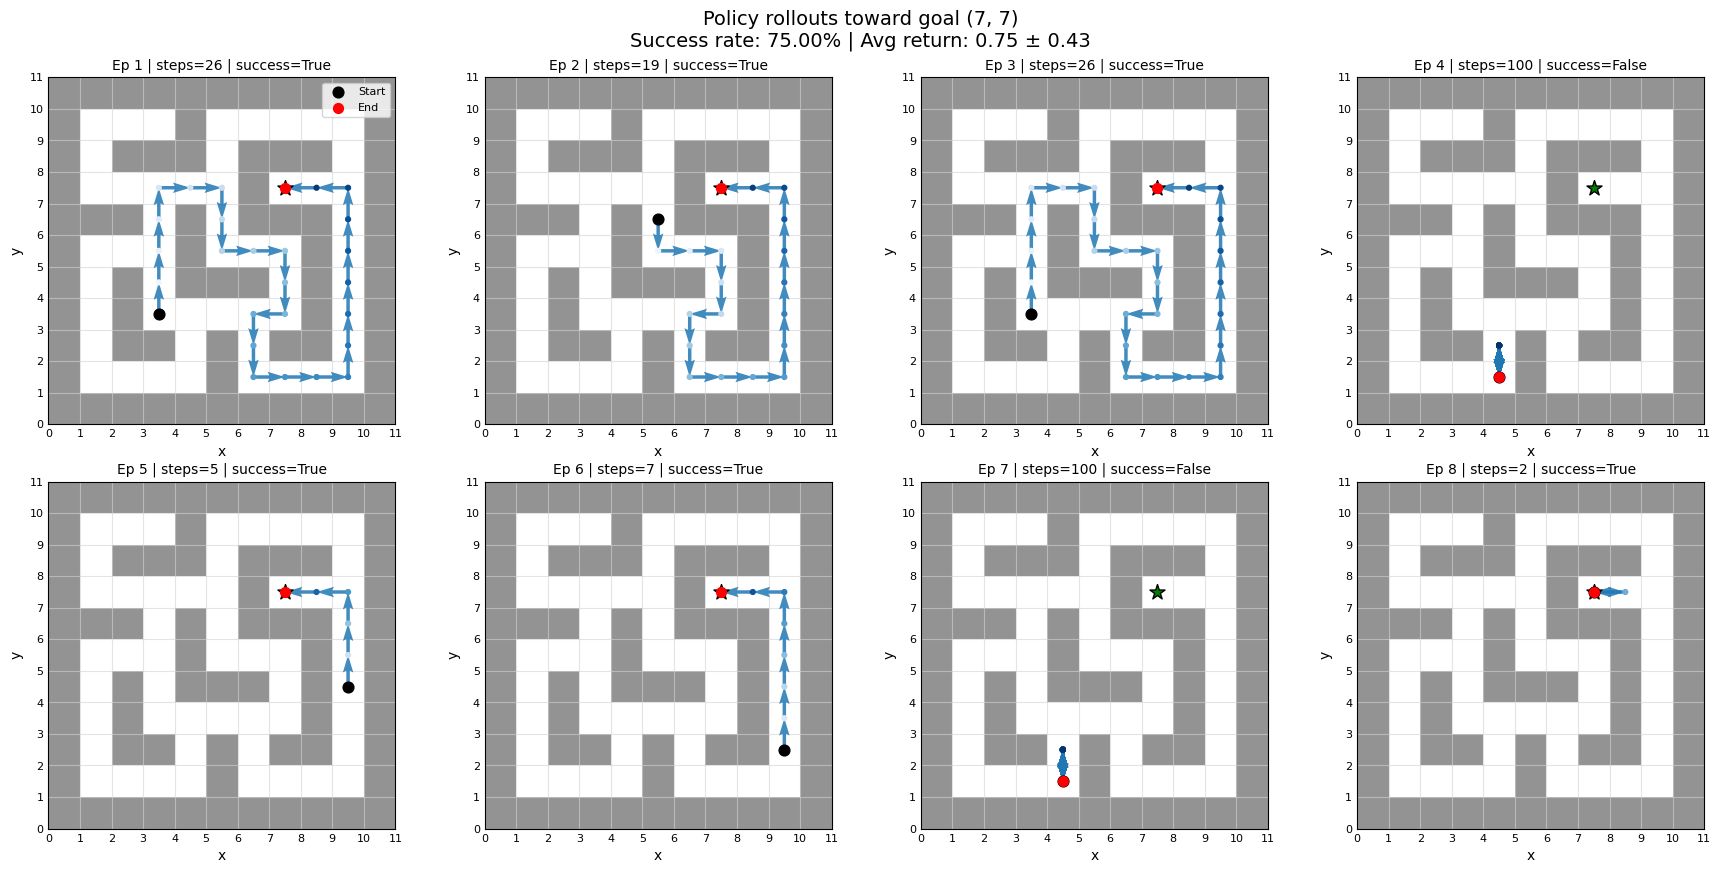

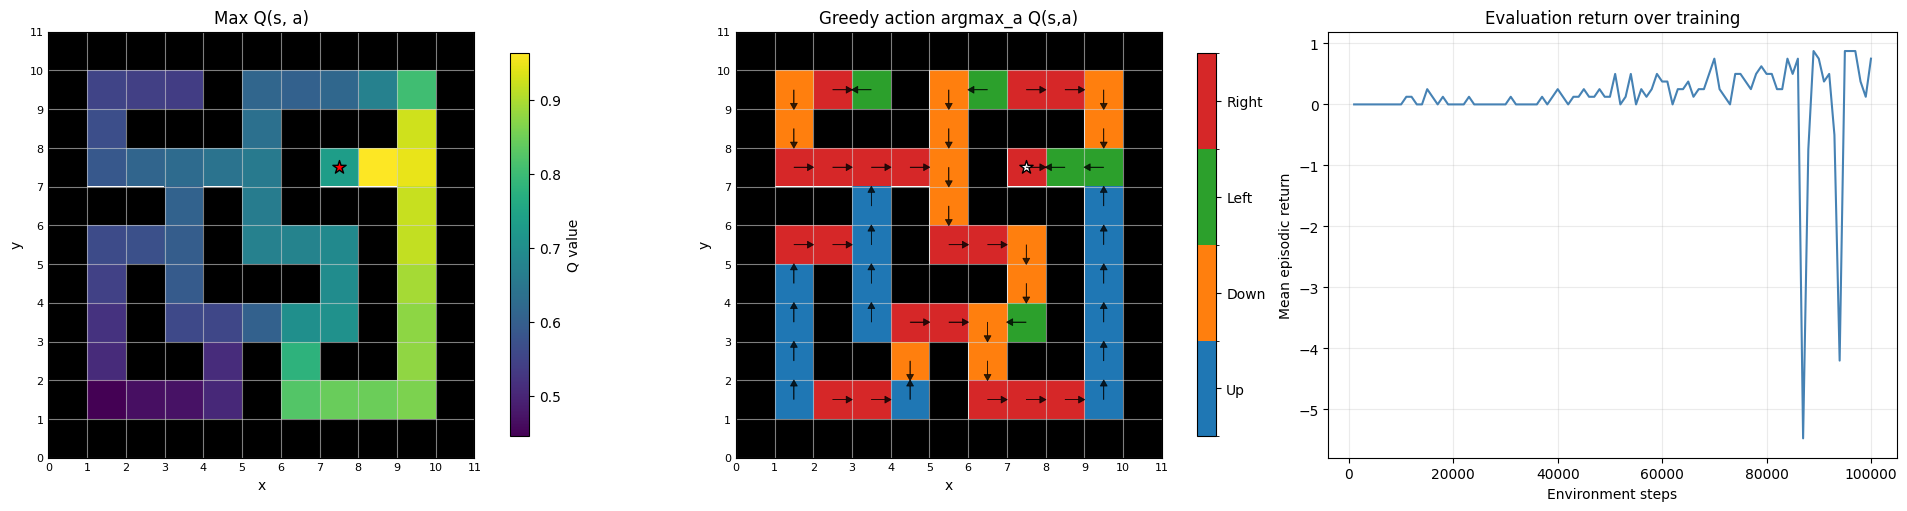

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 16)
psi(z) / task code base: (1, 16)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [3.6687822 3.27393   2.9004245 2.2491944 2.029662 ]
cumulative variance (first 5 dims): [0.25588706 0.4596585  0.61958766 0.71576184 0.7940781 ]
cos(phi(s,a), psi/task): mean=0.6111, std=0.1395


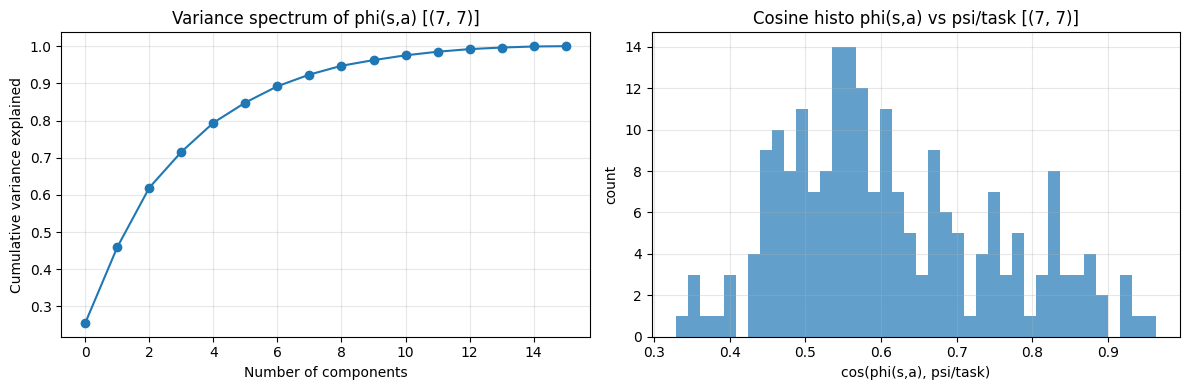


Goal embedding cosine similarity matrix:
     task_0     task_1     task_2     task_3
  task_0      1.000      0.954      0.911      0.687
  task_1      0.954      1.000      0.890      0.721
  task_2      0.911      0.890      1.000      0.815
  task_3      0.687      0.721      0.815      1.000

Off-diagonal mean similarity: 0.830
Off-diagonal min similarity: 0.687
Off-diagonal max similarity: 0.954

----- seed=42, task_idx=4, goal=(4, 2) -----

[DQN-factorised] step=   1000 | eps=0.981 | eval_return=0.750 | eval_len=30.5 | TD=0.000000 | ReplayTD=0.000000 | Ortho=0.000000 | SigReg=0.000000 | EWC=0.000000 | Loss=0.000000| goal_reg_loss=0.000000
[DQN-factorised] step=   2000 | eps=0.962 | eval_return=0.875 | eval_len=17.0 | TD=0.000000 | ReplayTD=0.000000 | Ortho=0.000000 | SigReg=0.000000 | EWC=0.000000 | Loss=0.000000| goal_reg_loss=0.000000
[DQN-factorised] step=   3000 | eps=0.943 | eval_return=0.375 | eval_len=65.8 | TD=0.000000 | ReplayTD=0.000000 | Ortho=0.000000 | SigReg=0.000

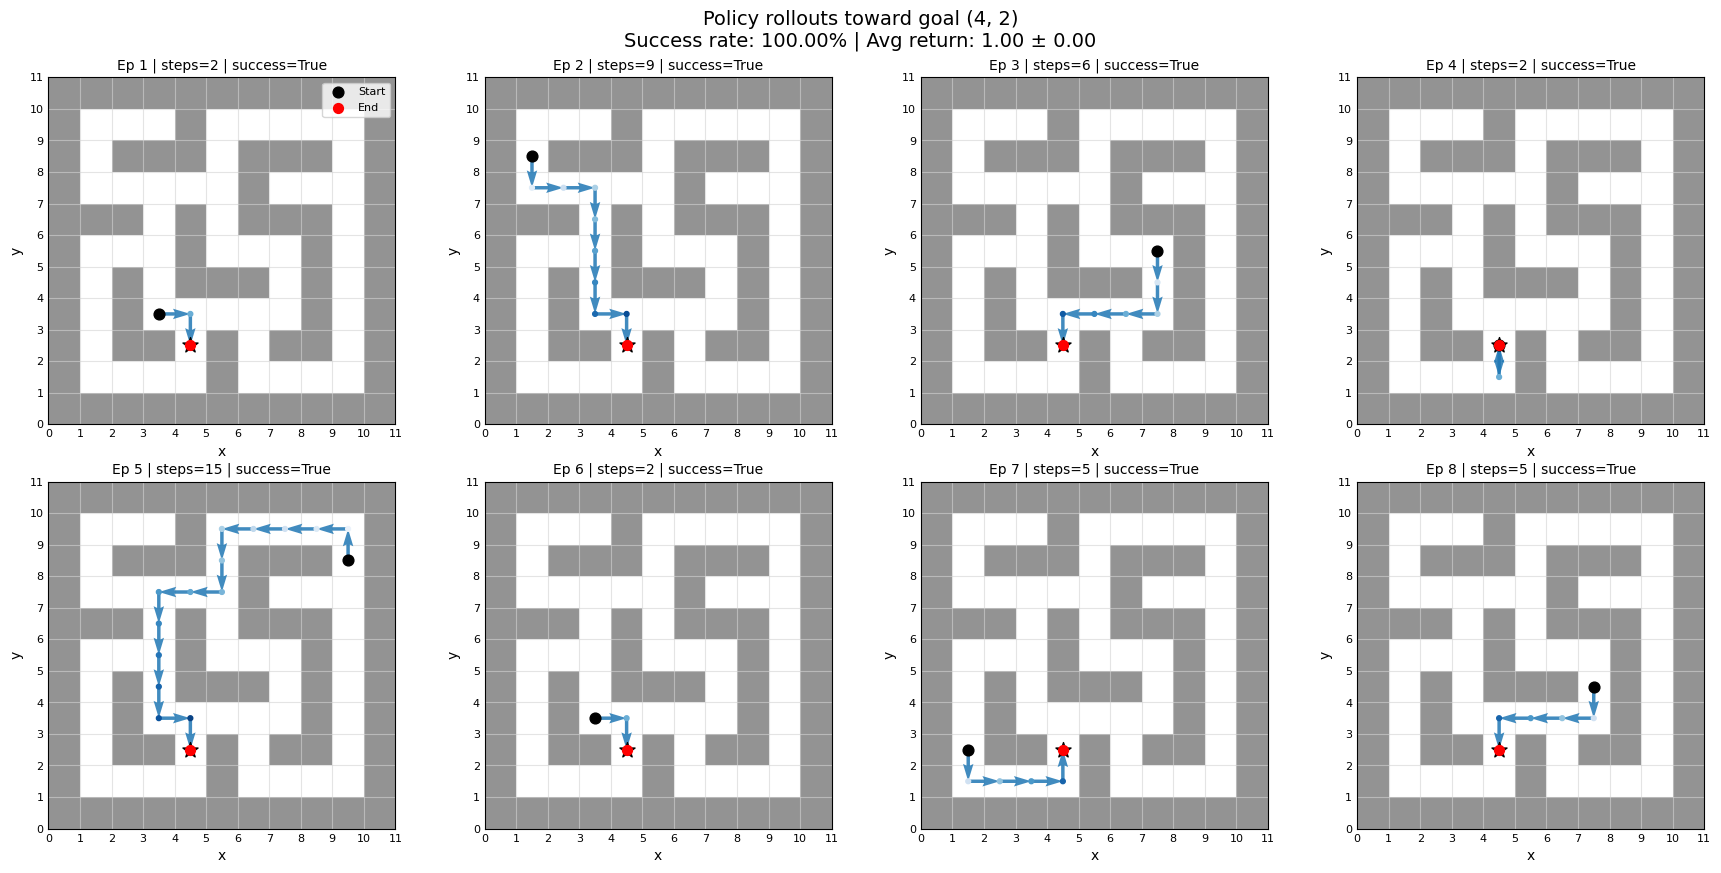

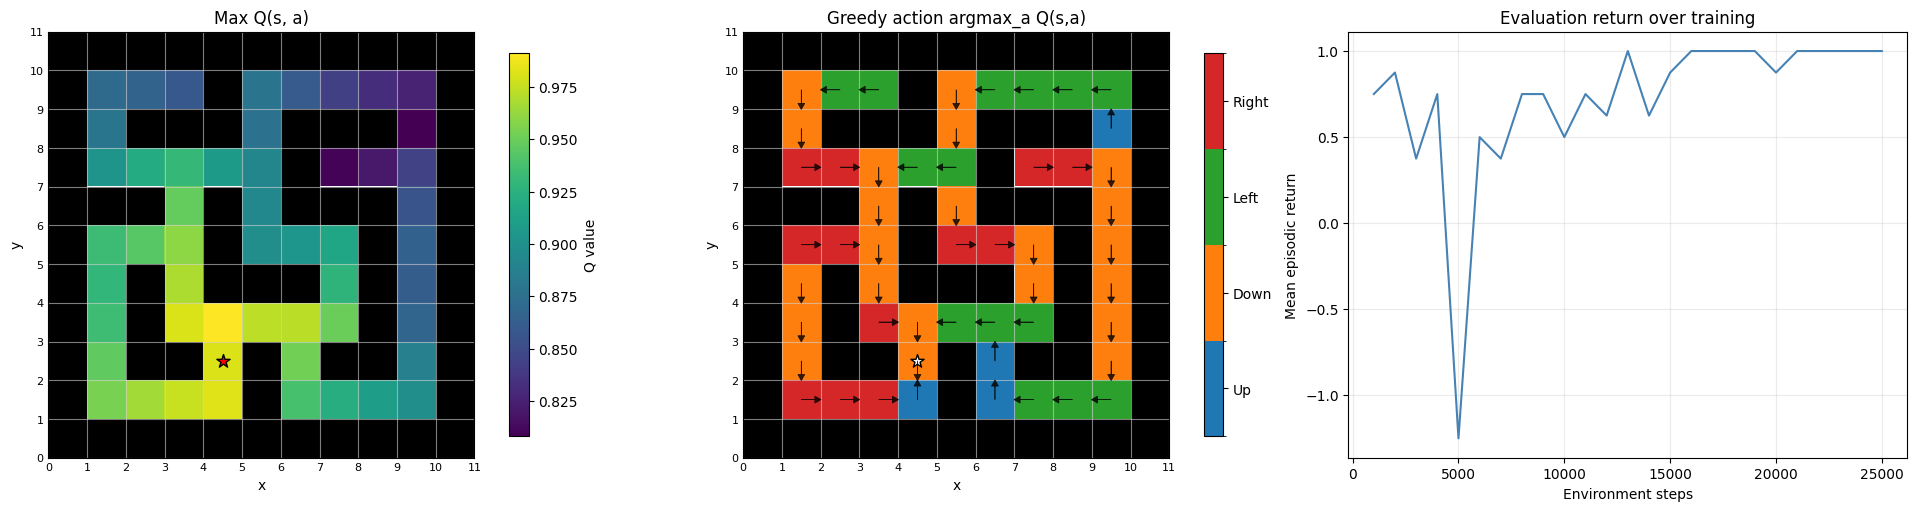

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 16)
psi(z) / task code base: (1, 16)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [3.699877  3.0755308 2.5662699 2.2927926 2.0617154]
cumulative variance (first 5 dims): [0.27215287 0.4602051  0.5911363  0.69564867 0.78015625]
cos(phi(s,a), psi/task): mean=0.8504, std=0.0710


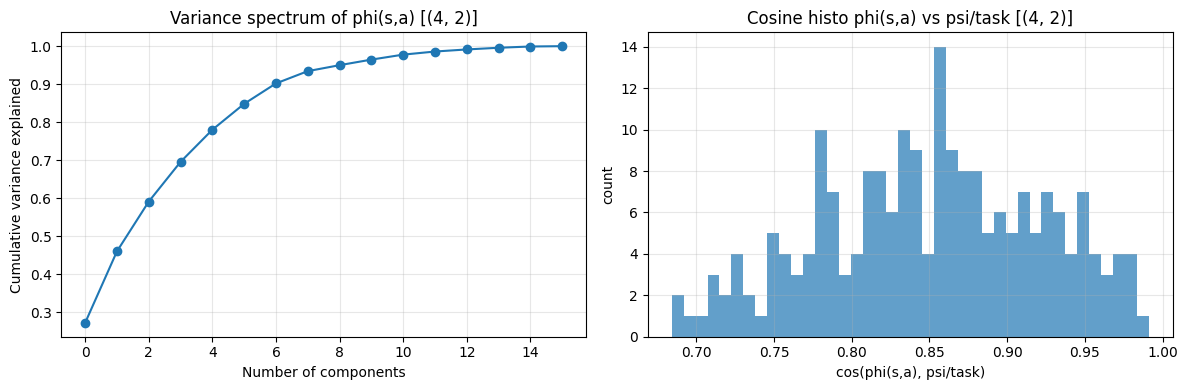


Goal embedding cosine similarity matrix:
     task_0     task_1     task_2     task_3     task_4
  task_0      1.000      0.954      0.911      0.687      0.811
  task_1      0.954      1.000      0.890      0.721      0.850
  task_2      0.911      0.890      1.000      0.815      0.779
  task_3      0.687      0.721      0.815      1.000      0.554
  task_4      0.811      0.850      0.779      0.554      1.000

Off-diagonal mean similarity: 0.797
Off-diagonal min similarity: 0.554
Off-diagonal max similarity: 0.954

----- seed=42, task_idx=5, goal=(5, 7) -----

[DQN-factorised] step=   1000 | eps=0.981 | eval_return=0.125 | eval_len=87.9 | TD=0.000000 | ReplayTD=0.000000 | Ortho=0.000000 | SigReg=0.000000 | EWC=0.000000 | Loss=0.000000| goal_reg_loss=0.000000
[DQN-factorised] step=   2000 | eps=0.962 | eval_return=0.250 | eval_len=75.9 | TD=0.000000 | ReplayTD=0.000000 | Ortho=0.000000 | SigReg=0.000000 | EWC=0.000000 | Loss=0.000000| goal_reg_loss=0.000000
[DQN-factorised] step=  

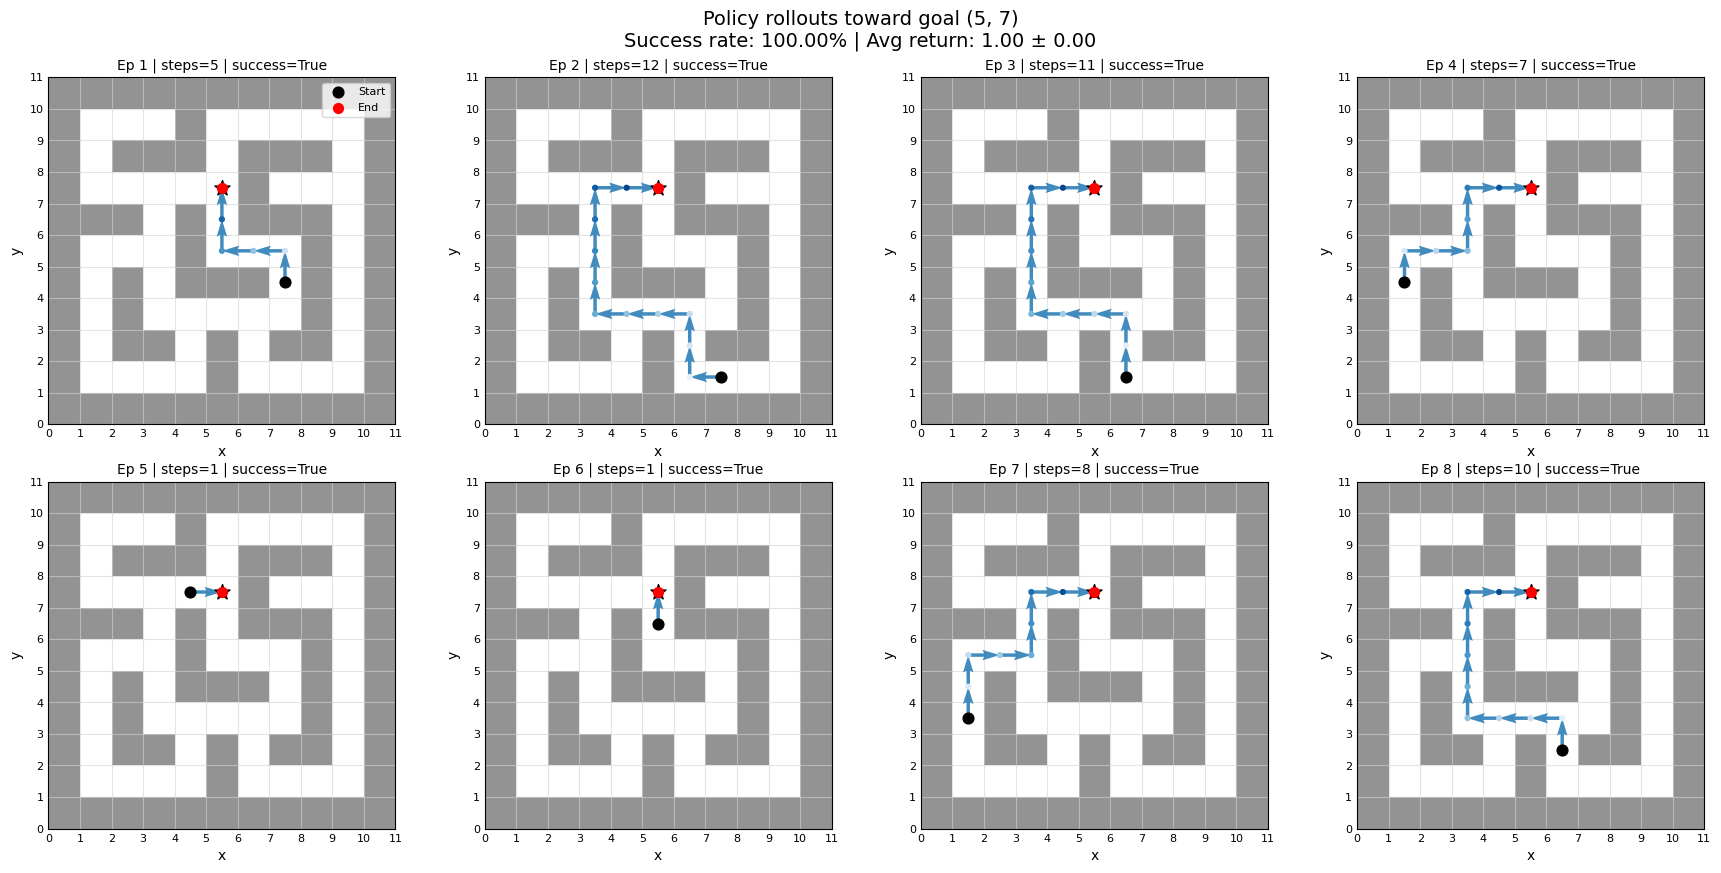

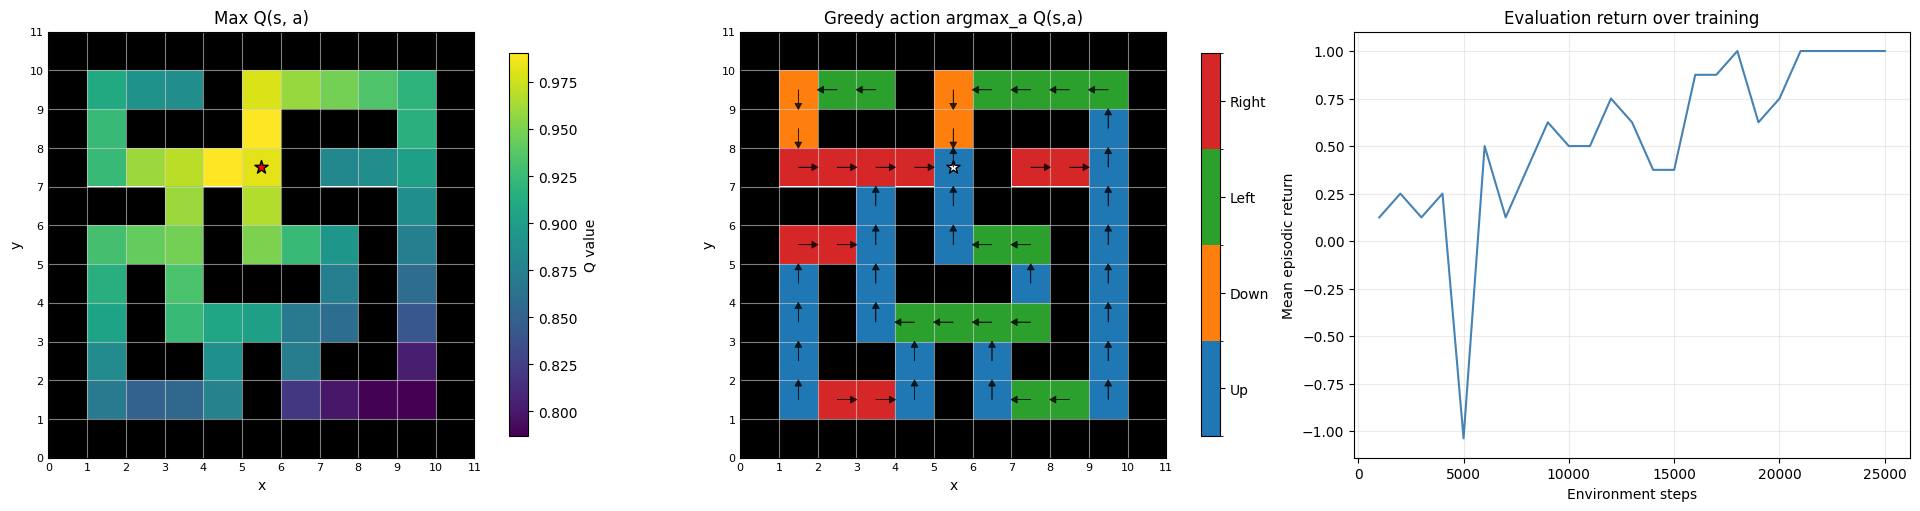

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 16)
psi(z) / task code base: (1, 16)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [3.7791224 2.9046514 2.4306042 2.2928643 1.8912362]
cumulative variance (first 5 dims): [0.29755548 0.47333735 0.596425   0.7059574  0.78047824]
cos(phi(s,a), psi/task): mean=0.8432, std=0.0720


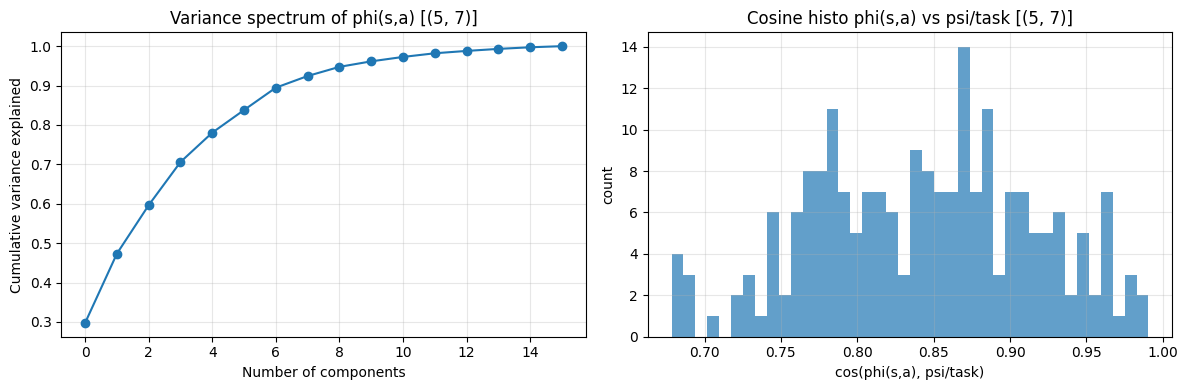


Goal embedding cosine similarity matrix:
     task_0     task_1     task_2     task_3     task_4     task_5
  task_0      1.000      0.954      0.911      0.687      0.811      0.801
  task_1      0.954      1.000      0.890      0.721      0.850      0.811
  task_2      0.911      0.890      1.000      0.815      0.779      0.867
  task_3      0.687      0.721      0.815      1.000      0.554      0.632
  task_4      0.811      0.850      0.779      0.554      1.000      0.892
  task_5      0.801      0.811      0.867      0.632      0.892      1.000

Off-diagonal mean similarity: 0.798
Off-diagonal min similarity: 0.554
Off-diagonal max similarity: 0.954

----- seed=42, task_idx=6, goal=(9, 8) -----

[DQN-factorised] step=   1000 | eps=0.981 | eval_return=0.000 | eval_len=100.0 | TD=0.000000 | ReplayTD=0.000000 | Ortho=0.000000 | SigReg=0.000000 | EWC=0.000000 | Loss=0.000000| goal_reg_loss=0.000000
[DQN-factorised] step=   2000 | eps=0.962 | eval_return=0.000 | eval_len=100.0 | TD=

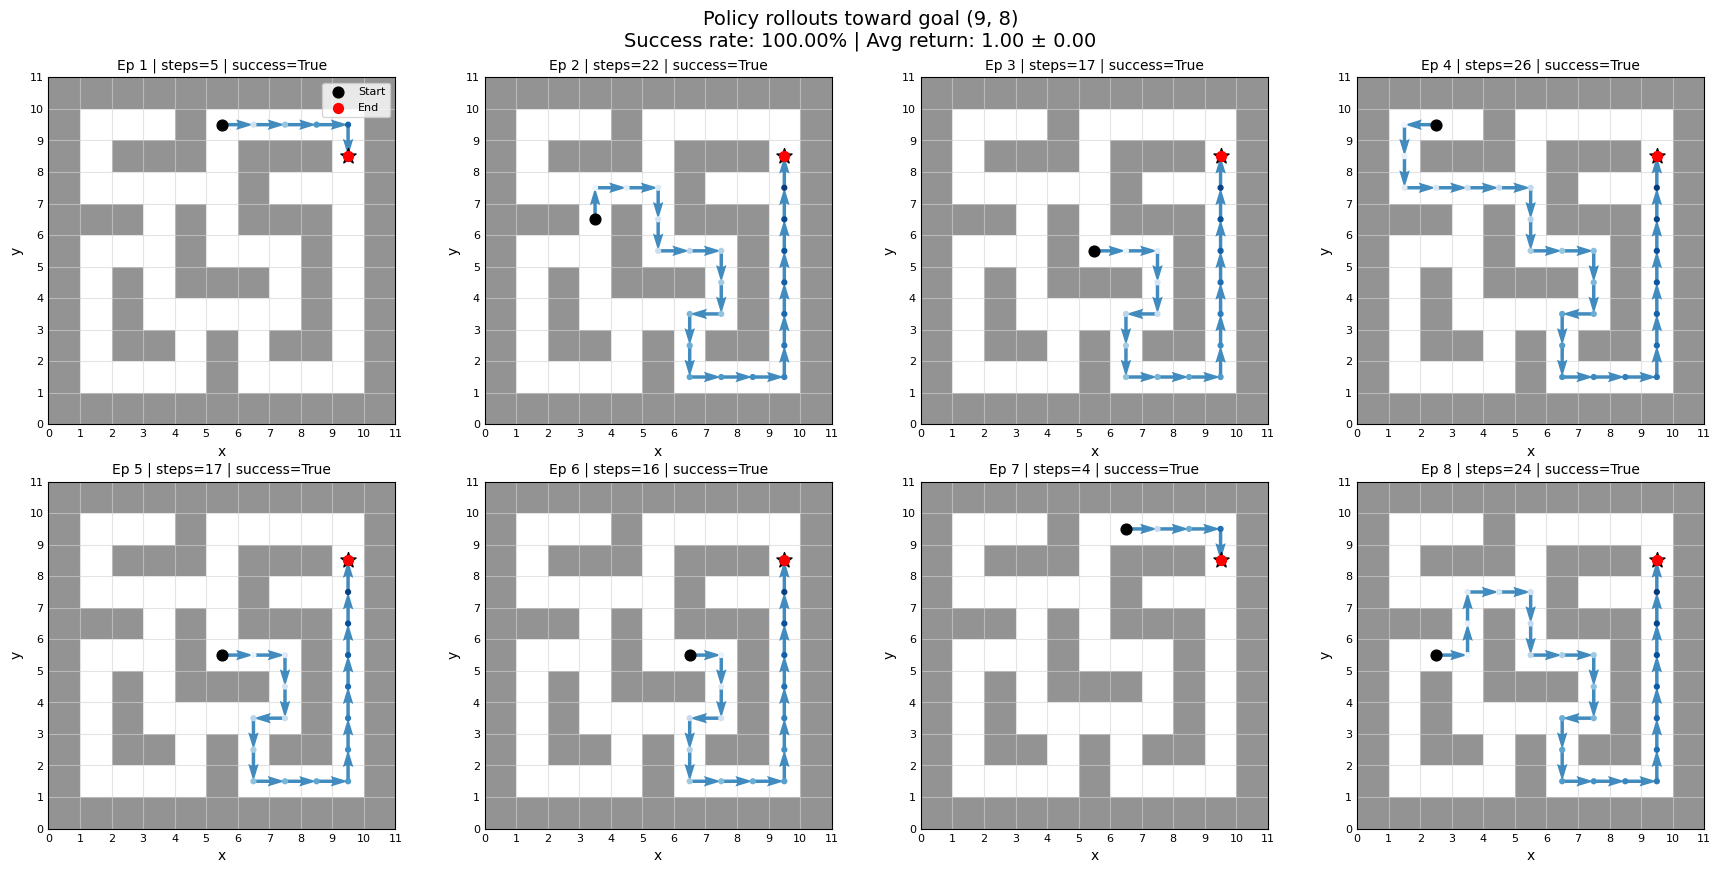

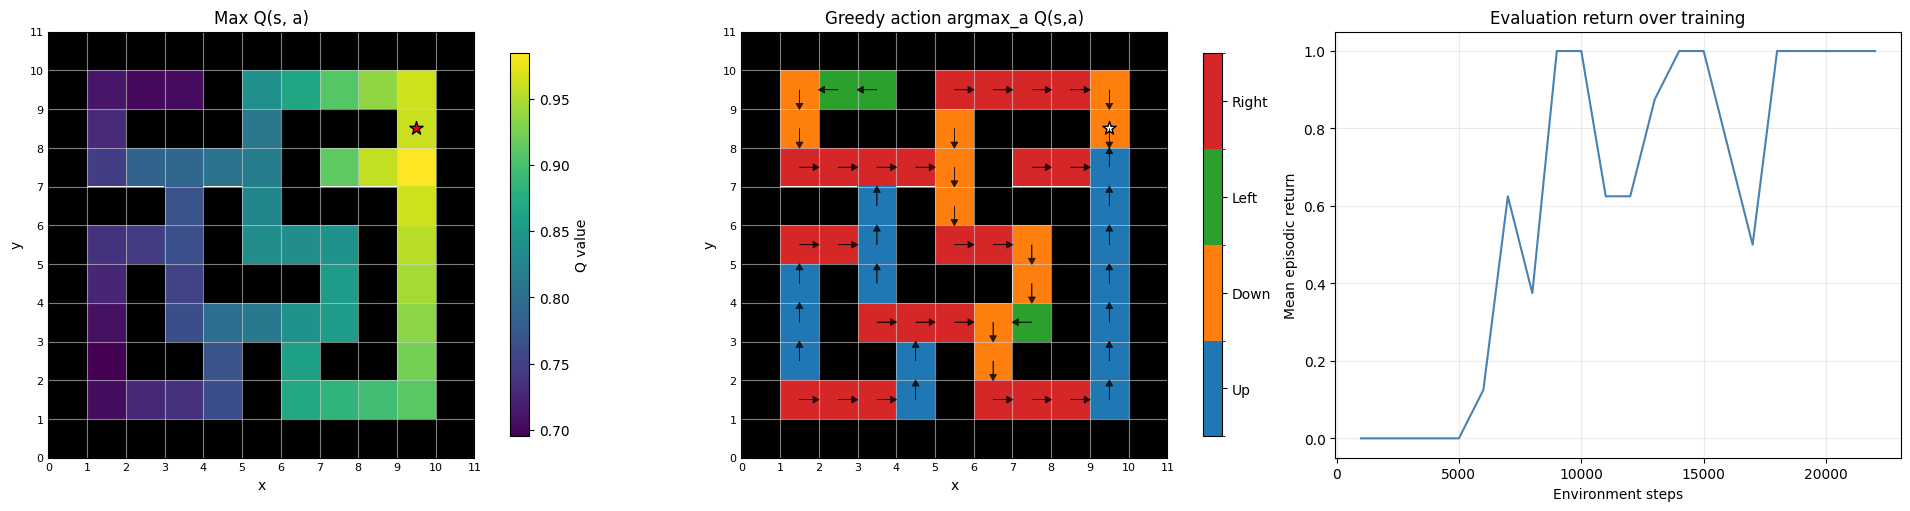

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 16)
psi(z) / task code base: (1, 16)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [3.59377   3.3605874 2.7873127 2.2607636 1.9695383]
cumulative variance (first 5 dims): [0.24749336 0.46391135 0.6127907  0.71073365 0.7850684 ]
cos(phi(s,a), psi/task): mean=0.7672, std=0.0980


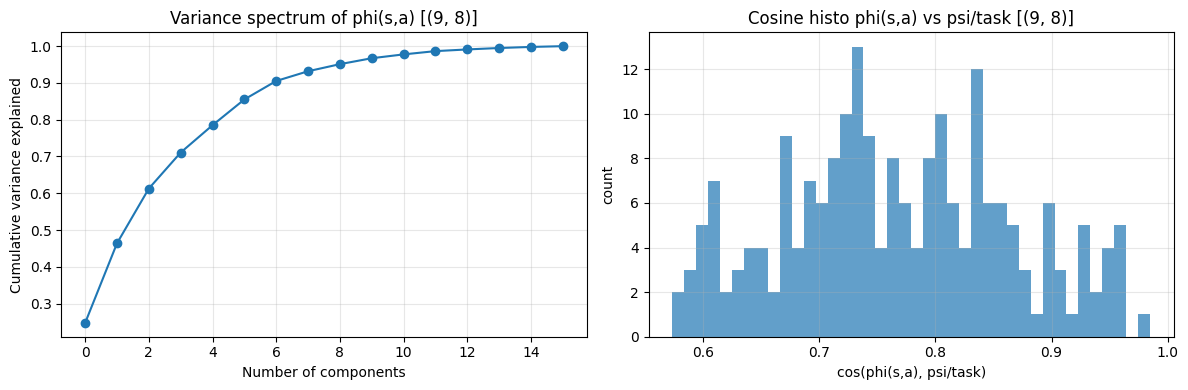


Goal embedding cosine similarity matrix:
     task_0     task_1     task_2     task_3     task_4     task_5     task_6
  task_0      1.000      0.954      0.911      0.687      0.811      0.801      0.791
  task_1      0.954      1.000      0.890      0.721      0.850      0.811      0.814
  task_2      0.911      0.890      1.000      0.815      0.779      0.867      0.860
  task_3      0.687      0.721      0.815      1.000      0.554      0.632      0.871
  task_4      0.811      0.850      0.779      0.554      1.000      0.892      0.803
  task_5      0.801      0.811      0.867      0.632      0.892      1.000      0.841
  task_6      0.791      0.814      0.860      0.871      0.803      0.841      1.000

Off-diagonal mean similarity: 0.807
Off-diagonal min similarity: 0.554
Off-diagonal max similarity: 0.954

----- seed=42, task_idx=7, goal=(7, 9) -----

[DQN-factorised] step=   1000 | eps=0.981 | eval_return=0.125 | eval_len=87.8 | TD=0.000000 | ReplayTD=0.000000 | Ortho=0.00

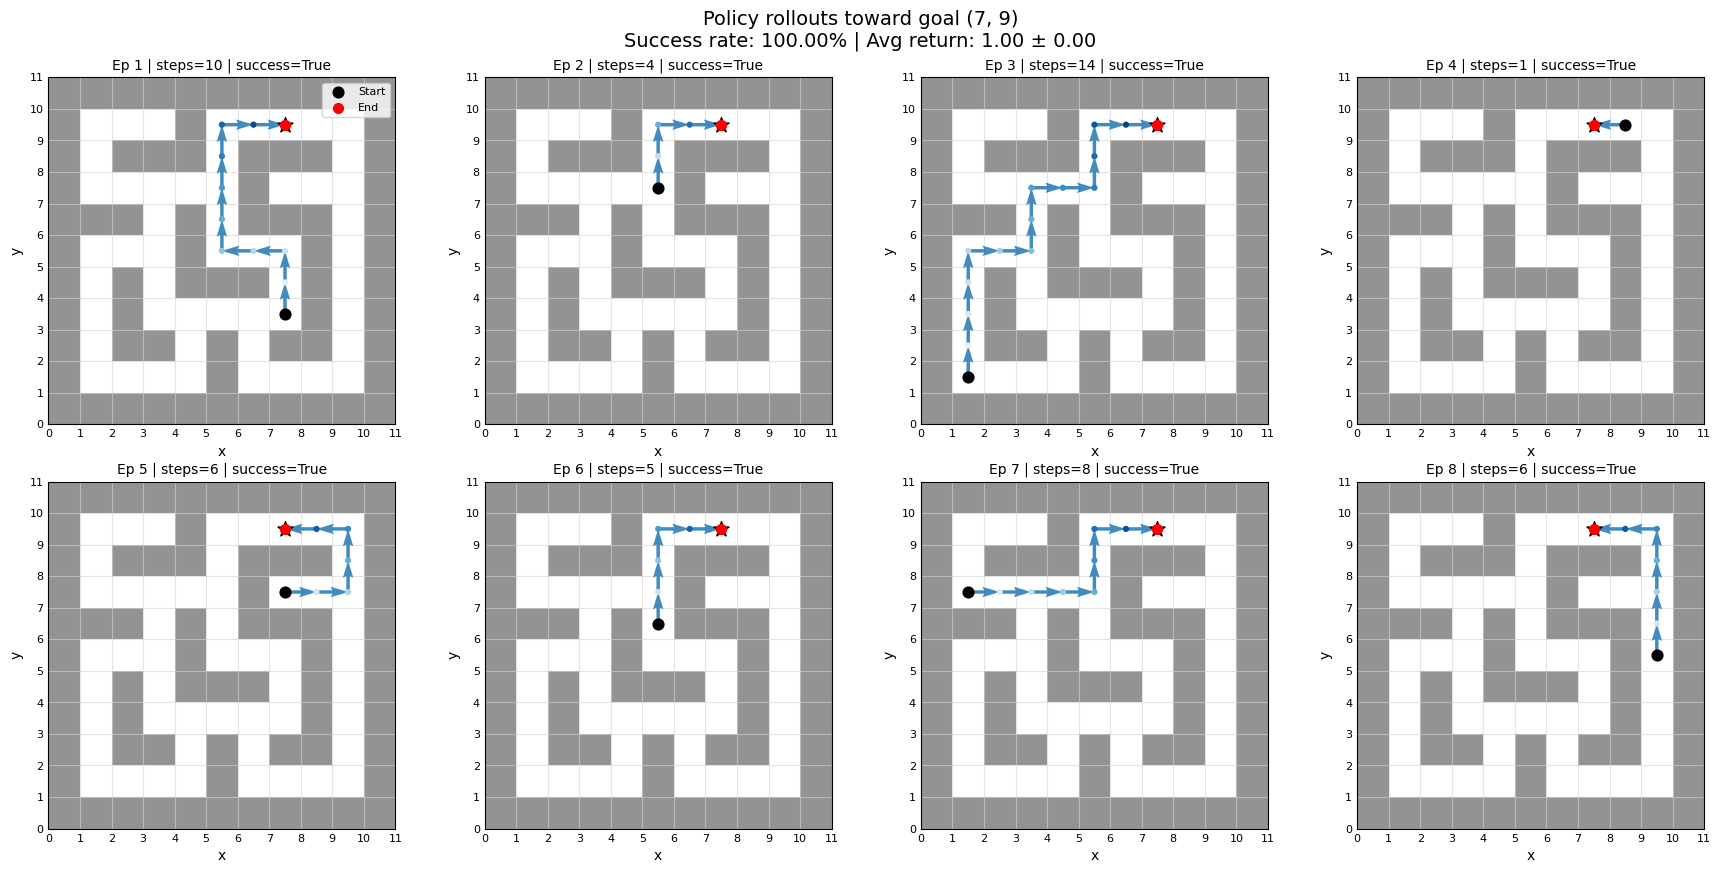

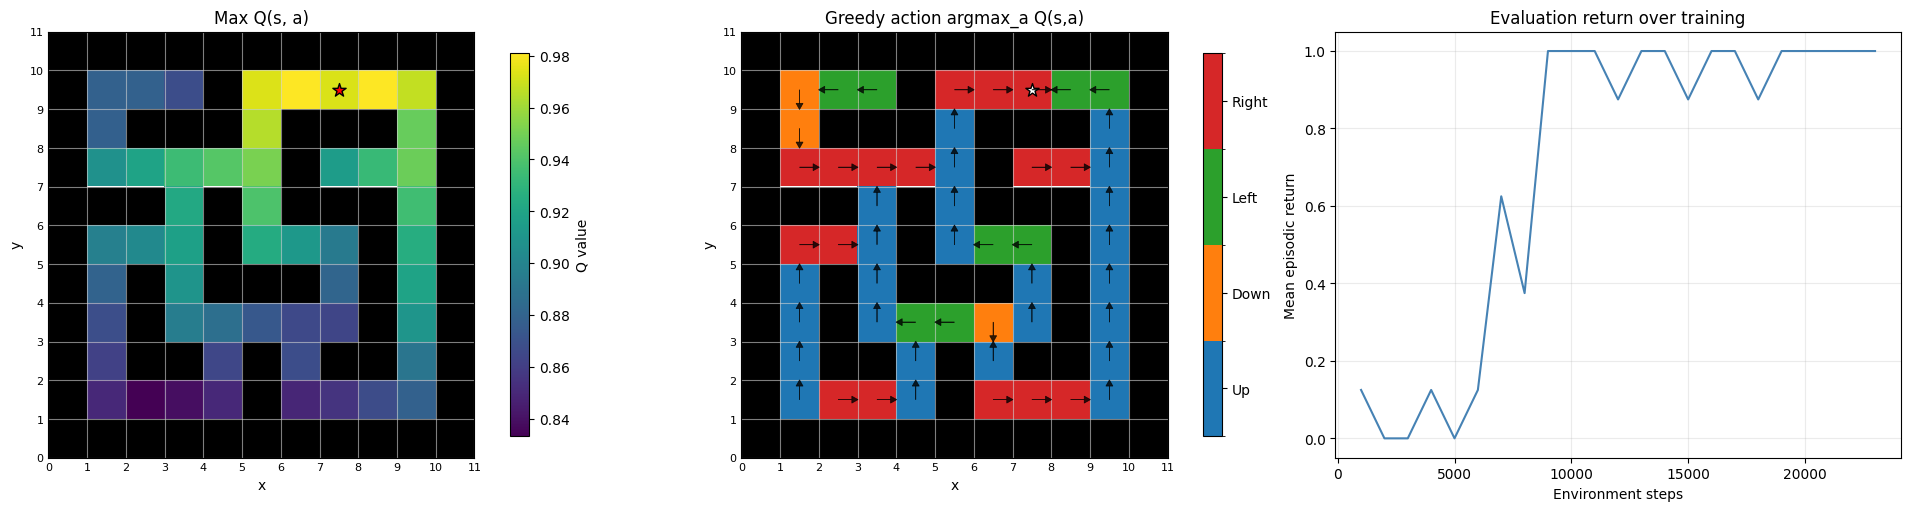

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 16)
psi(z) / task code base: (1, 16)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [3.7355857 2.930892  2.602938  2.194931  2.0206378]
cumulative variance (first 5 dims): [0.28284428 0.45695662 0.5942842  0.69193405 0.77469146]
cos(phi(s,a), psi/task): mean=0.8455, std=0.0640


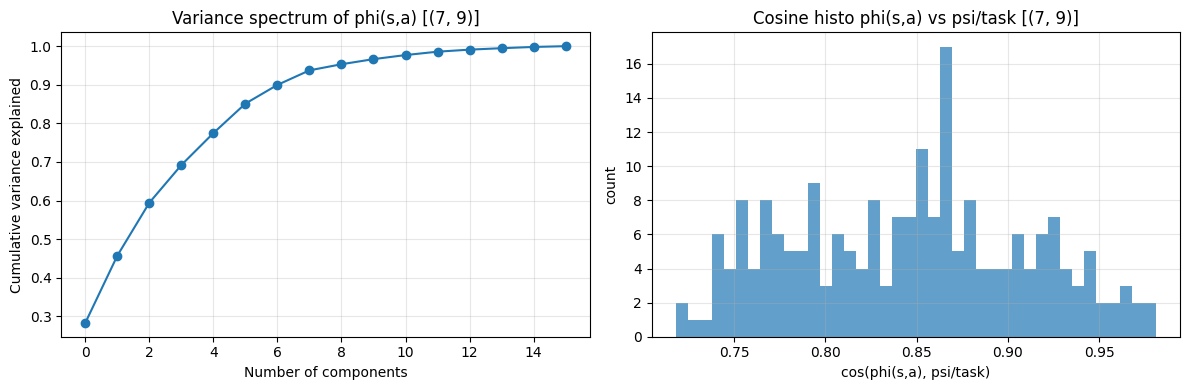


Goal embedding cosine similarity matrix:
     task_0     task_1     task_2     task_3     task_4     task_5     task_6     task_7
  task_0      1.000      0.954      0.911      0.687      0.811      0.801      0.791      0.827
  task_1      0.954      1.000      0.890      0.721      0.850      0.811      0.814      0.832
  task_2      0.911      0.890      1.000      0.815      0.779      0.867      0.860      0.858
  task_3      0.687      0.721      0.815      1.000      0.554      0.632      0.871      0.686
  task_4      0.811      0.850      0.779      0.554      1.000      0.892      0.803      0.900
  task_5      0.801      0.811      0.867      0.632      0.892      1.000      0.841      0.968
  task_6      0.791      0.814      0.860      0.871      0.803      0.841      1.000      0.891
  task_7      0.827      0.832      0.858      0.686      0.900      0.968      0.891      1.000

Off-diagonal mean similarity: 0.818
Off-diagonal min similarity: 0.554
Off-diagonal max simi

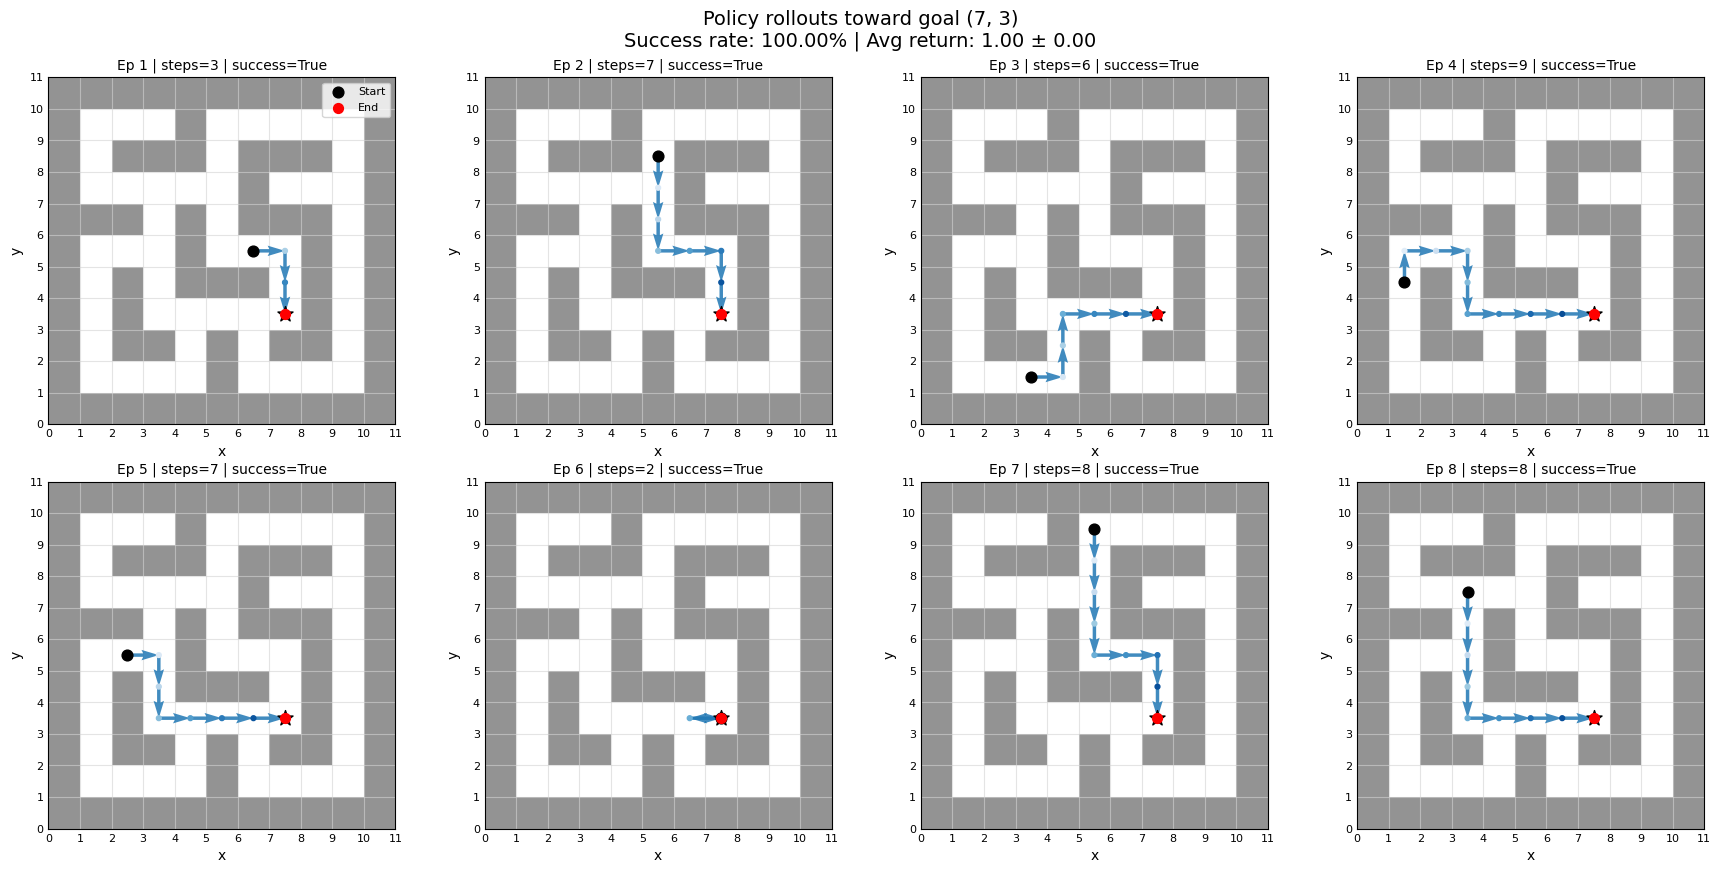

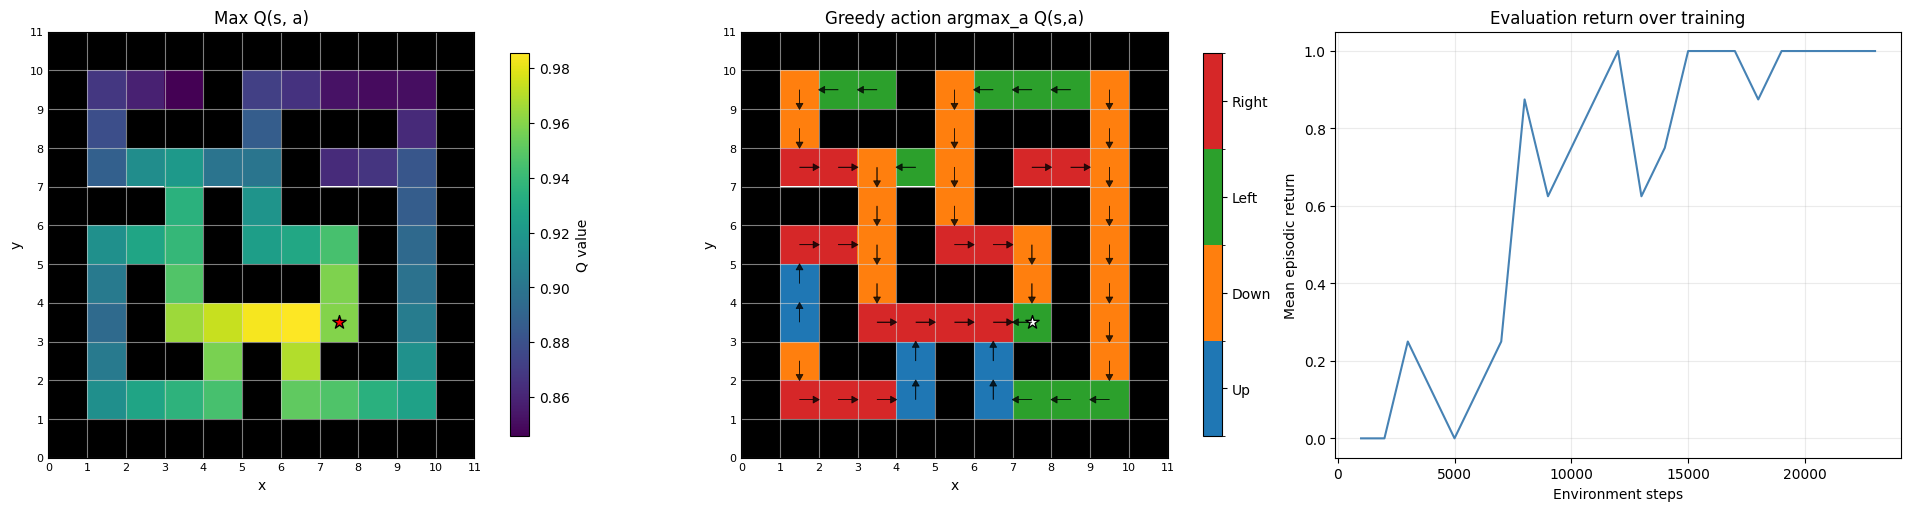

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 16)
psi(z) / task code base: (1, 16)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [3.7382607 2.8918037 2.5077085 2.2783232 2.0969052]
cumulative variance (first 5 dims): [0.2837901  0.4536128  0.5813191  0.68673074 0.7760234 ]
cos(phi(s,a), psi/task): mean=0.8549, std=0.0639


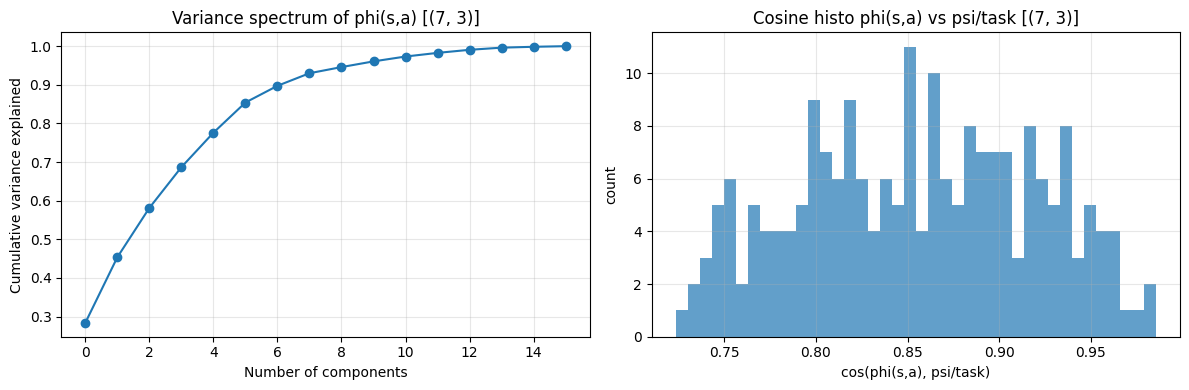


Goal embedding cosine similarity matrix:
     task_0     task_1     task_2     task_3     task_4     task_5     task_6     task_7     task_8
  task_0      1.000      0.954      0.911      0.687      0.811      0.801      0.791      0.827      0.769
  task_1      0.954      1.000      0.890      0.721      0.850      0.811      0.814      0.832      0.819
  task_2      0.911      0.890      1.000      0.815      0.779      0.867      0.860      0.858      0.747
  task_3      0.687      0.721      0.815      1.000      0.554      0.632      0.871      0.686      0.630
  task_4      0.811      0.850      0.779      0.554      1.000      0.892      0.803      0.900      0.968
  task_5      0.801      0.811      0.867      0.632      0.892      1.000      0.841      0.968      0.860
  task_6      0.791      0.814      0.860      0.871      0.803      0.841      1.000      0.891      0.849
  task_7      0.827      0.832      0.858      0.686      0.900      0.968      0.891      1.000      

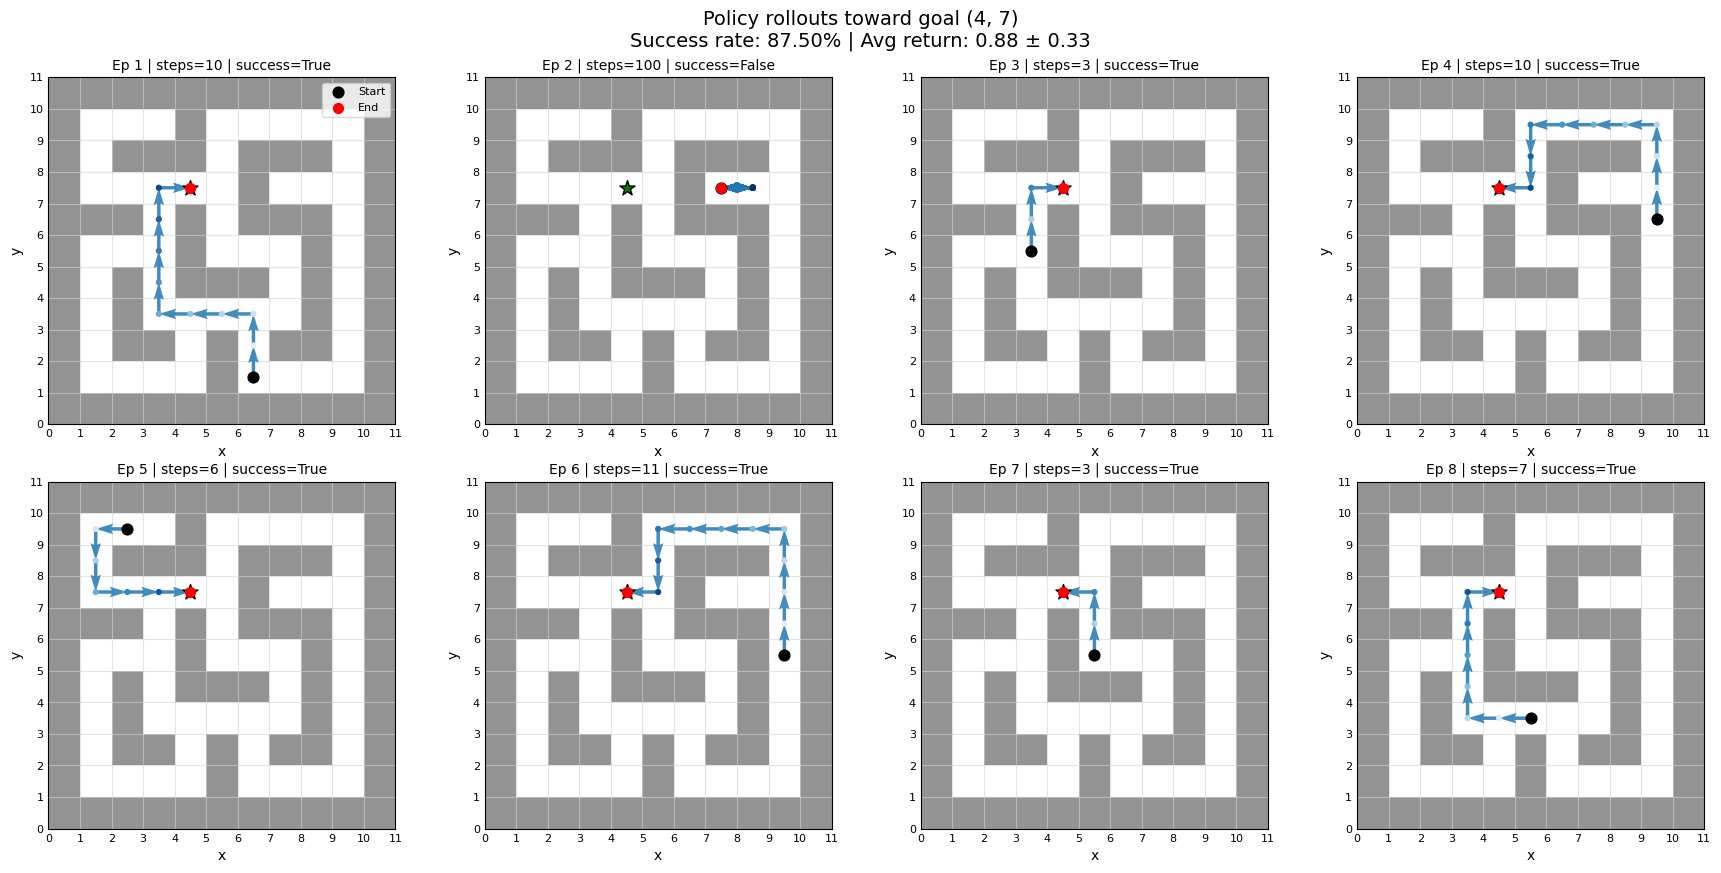

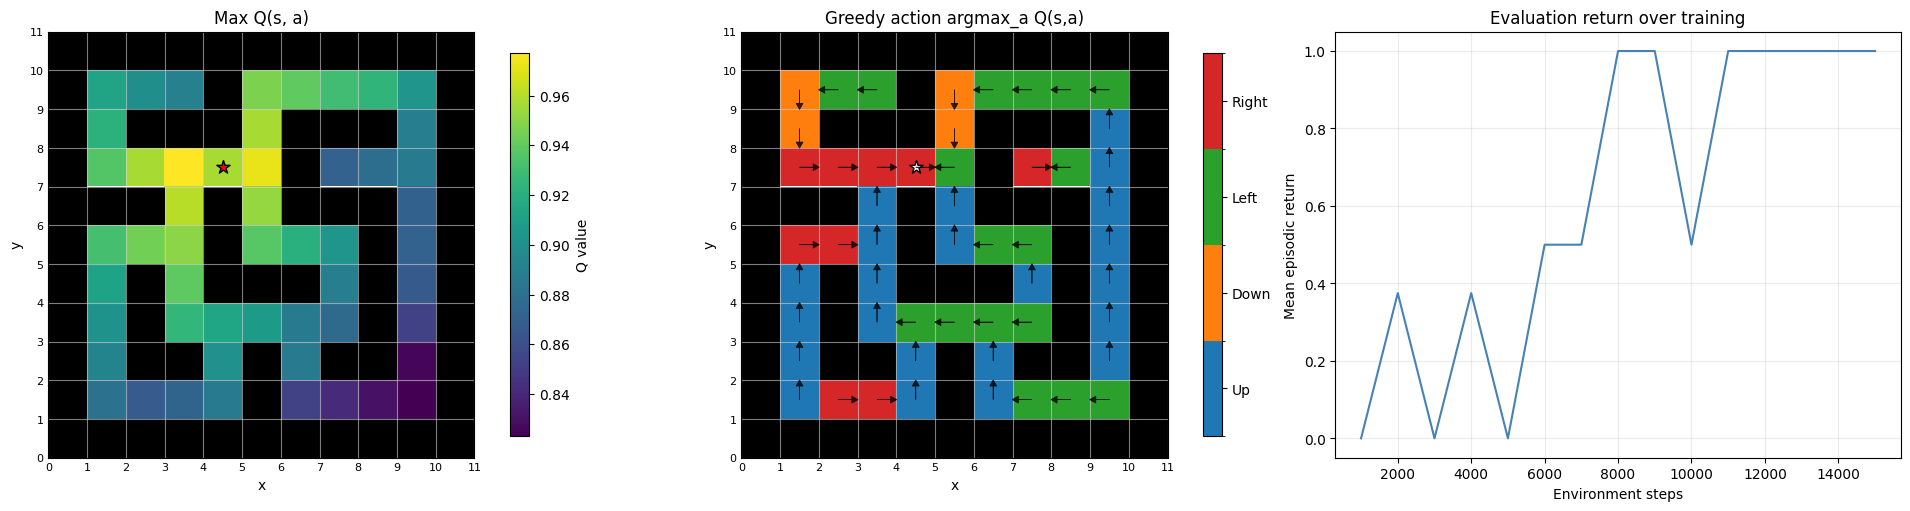

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 16)
psi(z) / task code base: (1, 16)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [3.8158143 2.9854114 2.5001078 2.2247224 2.0988026]
cumulative variance (first 5 dims): [0.28975934 0.46712574 0.5915143  0.69000936 0.7776703 ]
cos(phi(s,a), psi/task): mean=0.8453, std=0.0638


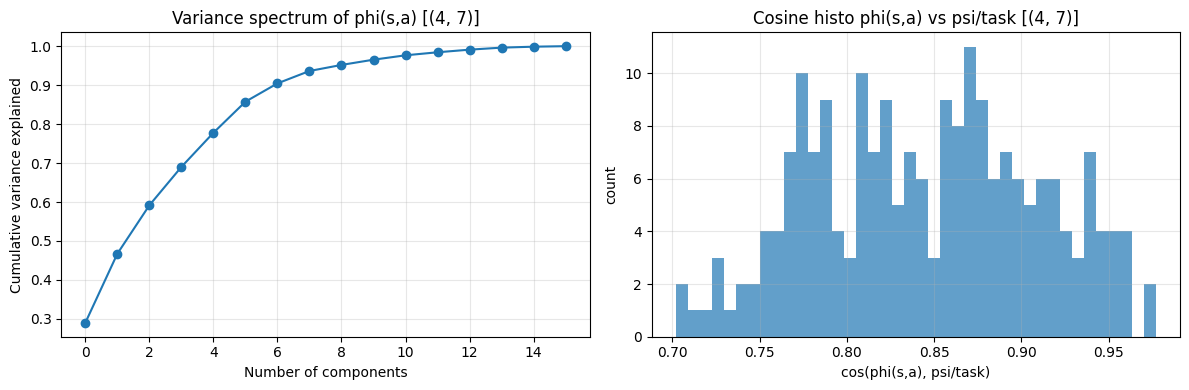


Goal embedding cosine similarity matrix:
     task_0     task_1     task_2     task_3     task_4     task_5     task_6     task_7     task_8     task_9
  task_0      1.000      0.954      0.911      0.687      0.811      0.801      0.791      0.827      0.769      0.769
  task_1      0.954      1.000      0.890      0.721      0.850      0.811      0.814      0.832      0.819      0.776
  task_2      0.911      0.890      1.000      0.815      0.779      0.867      0.860      0.858      0.747      0.775
  task_3      0.687      0.721      0.815      1.000      0.554      0.632      0.871      0.686      0.630      0.568
  task_4      0.811      0.850      0.779      0.554      1.000      0.892      0.803      0.900      0.968      0.911
  task_5      0.801      0.811      0.867      0.632      0.892      1.000      0.841      0.968      0.860      0.956
  task_6      0.791      0.814      0.860      0.871      0.803      0.841      1.000      0.891      0.849      0.806
  task_7      

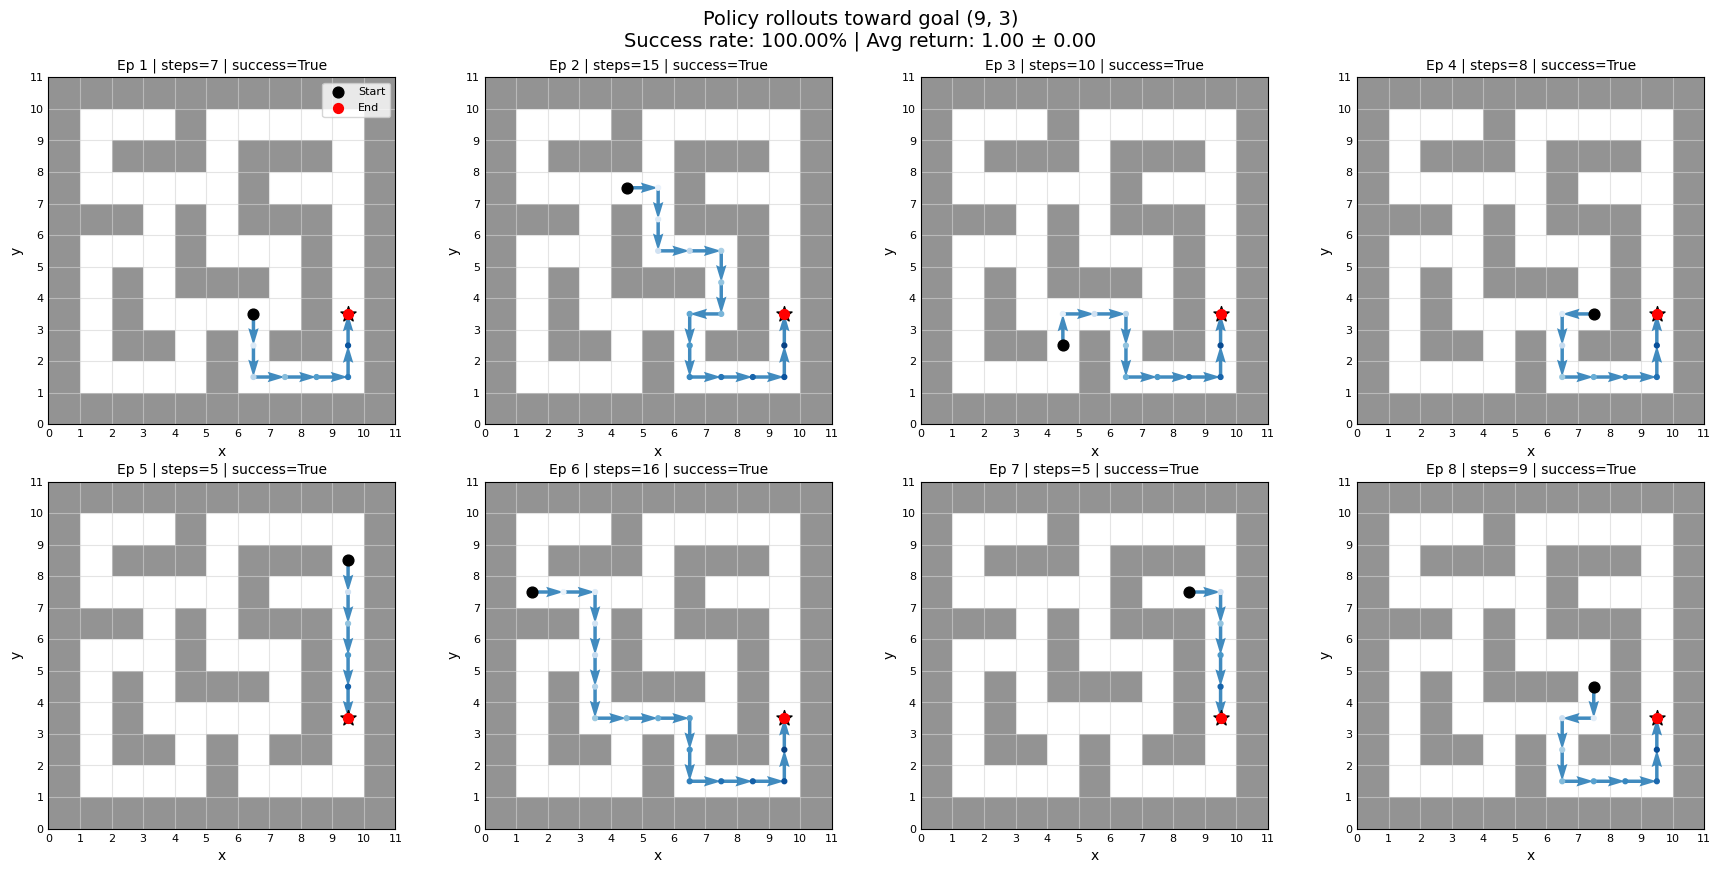

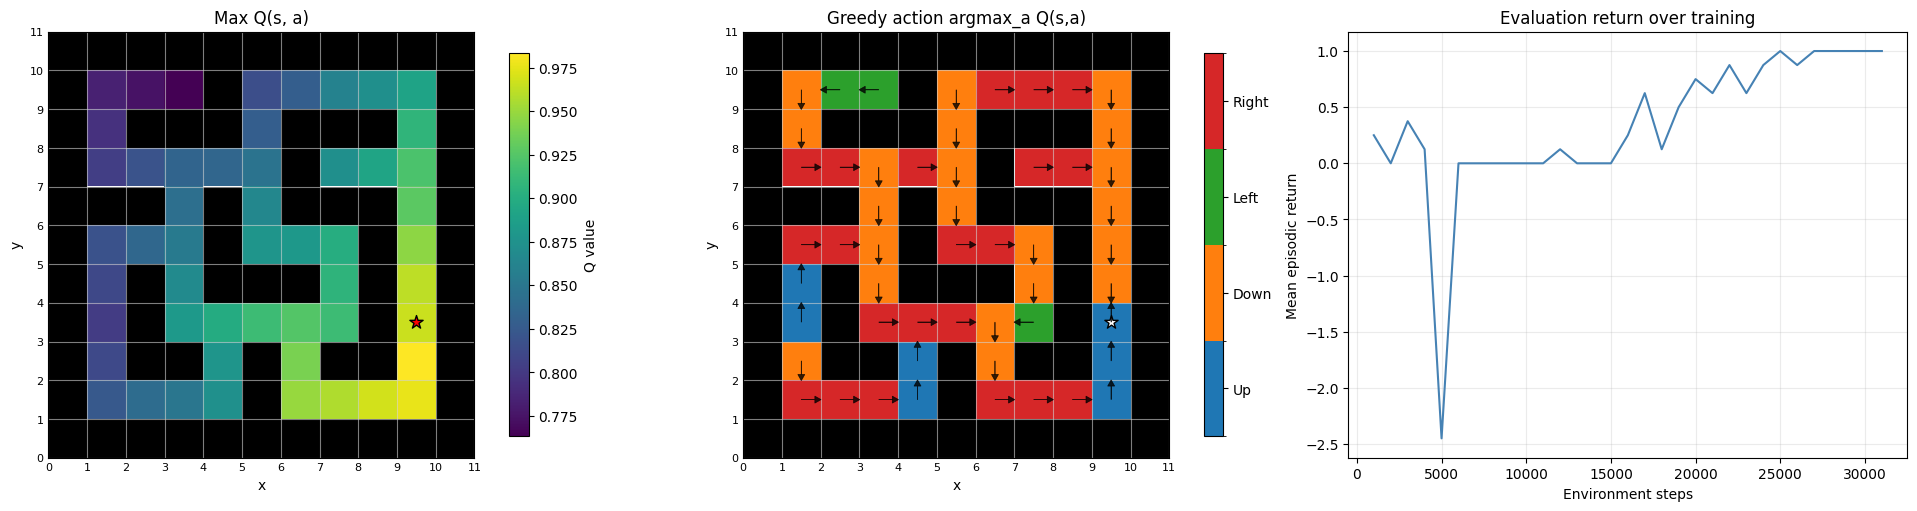

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 16)
psi(z) / task code base: (1, 16)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [3.805606  2.932969  2.3784938 2.2664144 2.0755498]
cumulative variance (first 5 dims): [0.29388037 0.4684376  0.58323365 0.6874658  0.7748815 ]
cos(phi(s,a), psi/task): mean=0.8157, std=0.0742


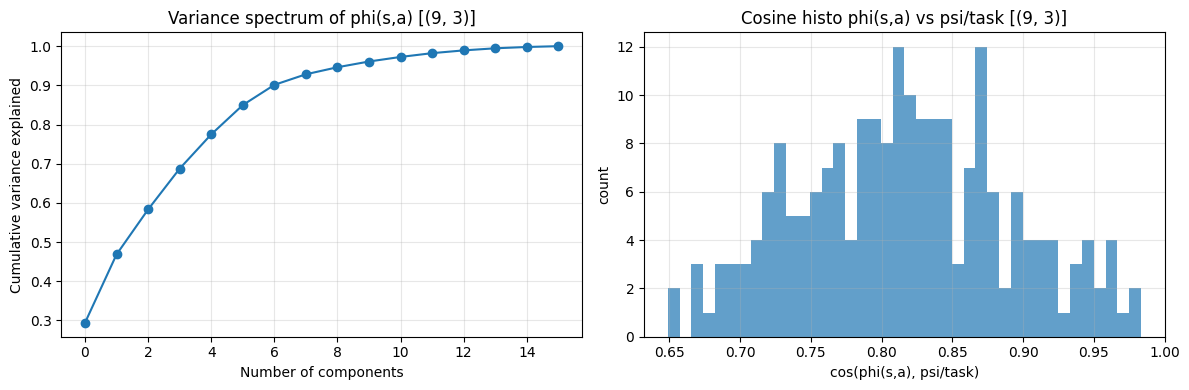


Goal embedding cosine similarity matrix:
     task_0     task_1     task_2     task_3     task_4     task_5     task_6     task_7     task_8     task_9    task_10
  task_0      1.000      0.954      0.911      0.687      0.811      0.801      0.791      0.827      0.769      0.769      0.755
  task_1      0.954      1.000      0.890      0.721      0.850      0.811      0.814      0.832      0.819      0.776      0.801
  task_2      0.911      0.890      1.000      0.815      0.779      0.867      0.860      0.858      0.747      0.775      0.775
  task_3      0.687      0.721      0.815      1.000      0.554      0.632      0.871      0.686      0.630      0.568      0.767
  task_4      0.811      0.850      0.779      0.554      1.000      0.892      0.803      0.900      0.968      0.911      0.901
  task_5      0.801      0.811      0.867      0.632      0.892      1.000      0.841      0.968      0.860      0.956      0.823
  task_6      0.791      0.814      0.860      0.871    

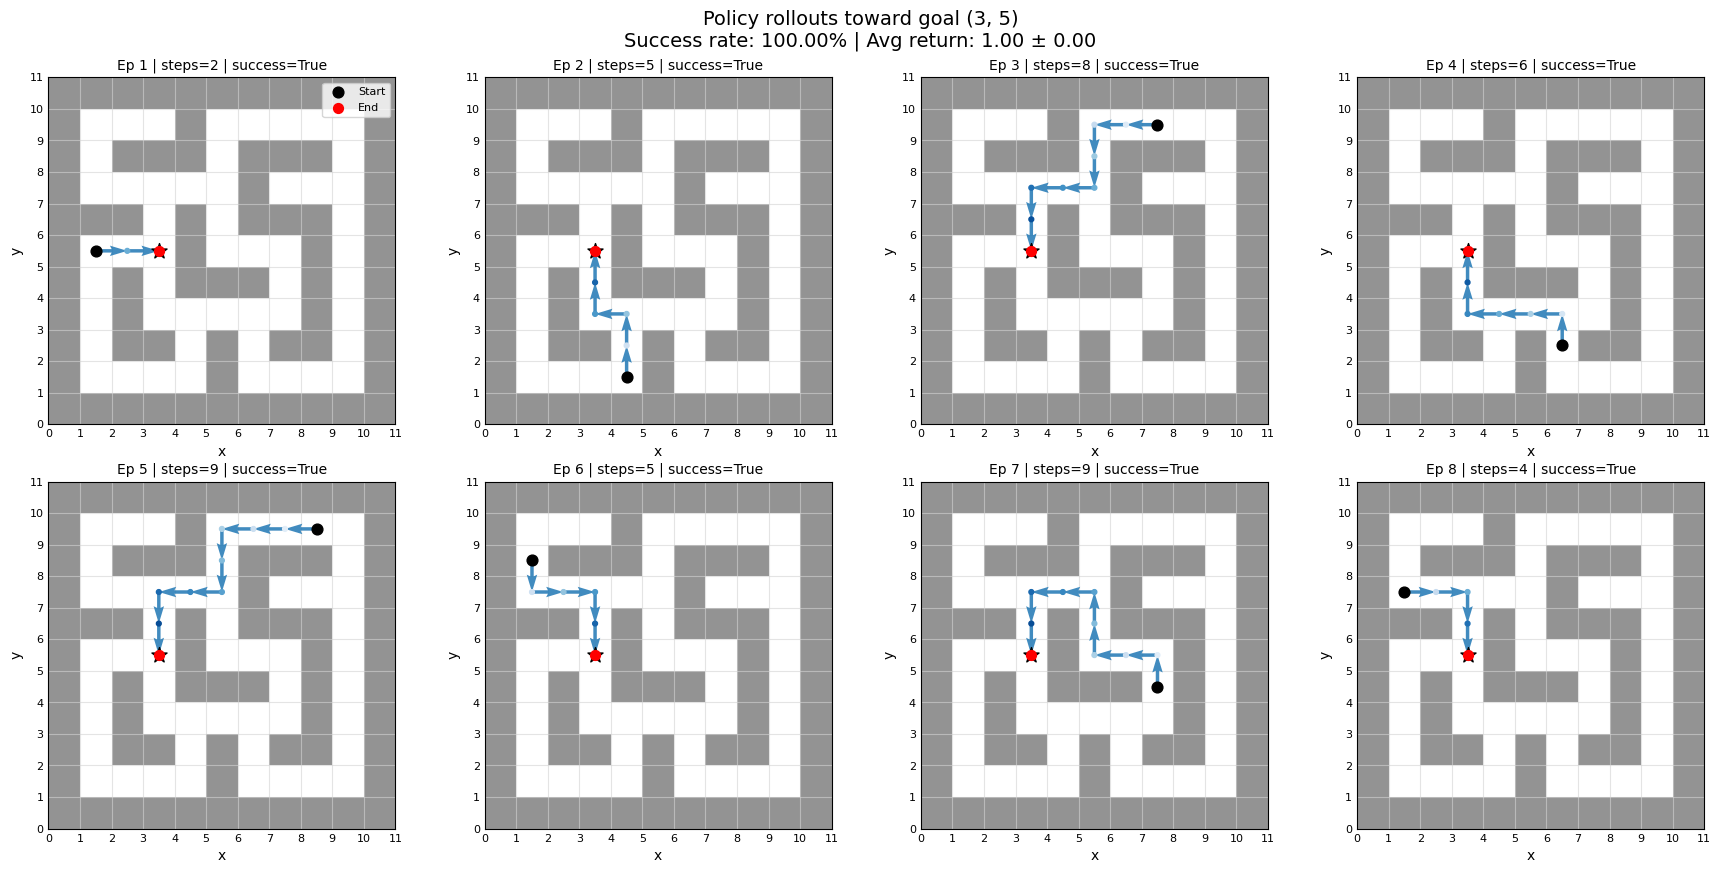

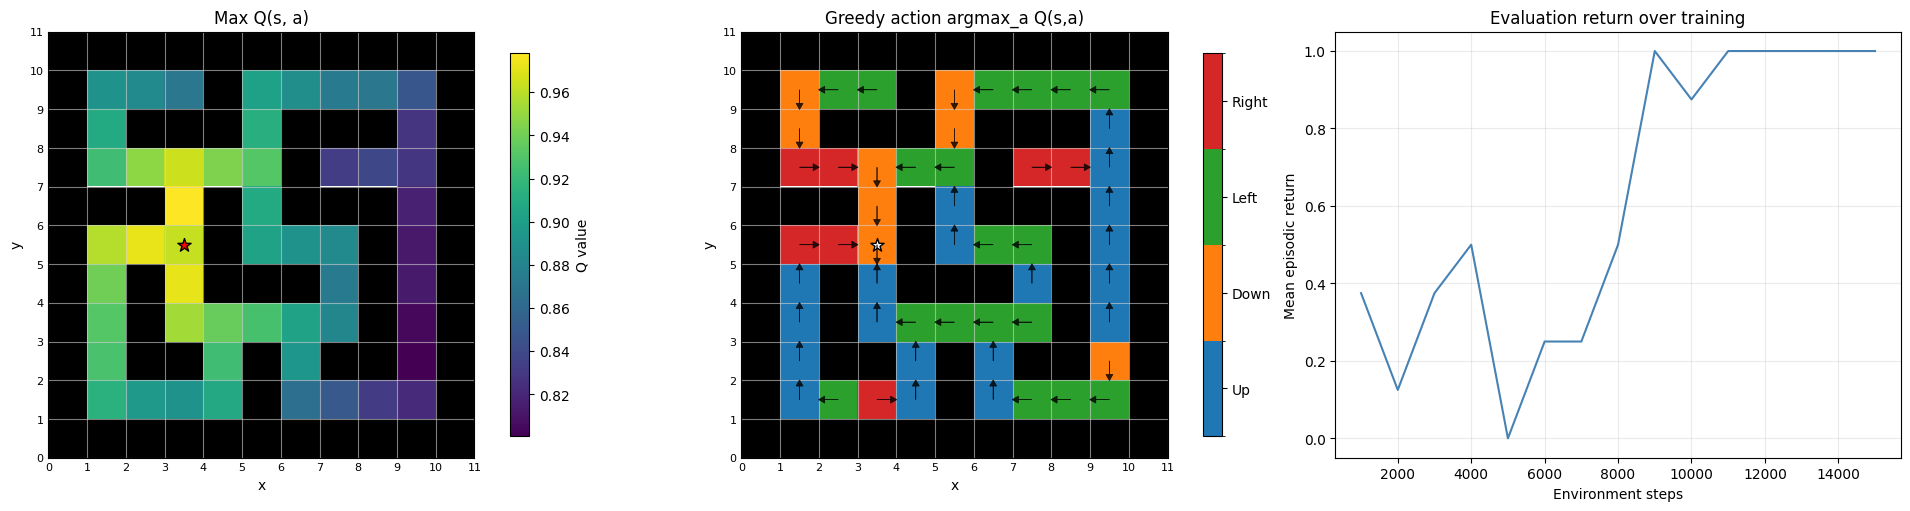

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 16)
psi(z) / task code base: (1, 16)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [3.9288523 3.0448961 2.3748894 2.2130835 1.9573734]
cumulative variance (first 5 dims): [0.31106248 0.49789876 0.61155754 0.71025634 0.78746456]
cos(phi(s,a), psi/task): mean=0.8354, std=0.0701


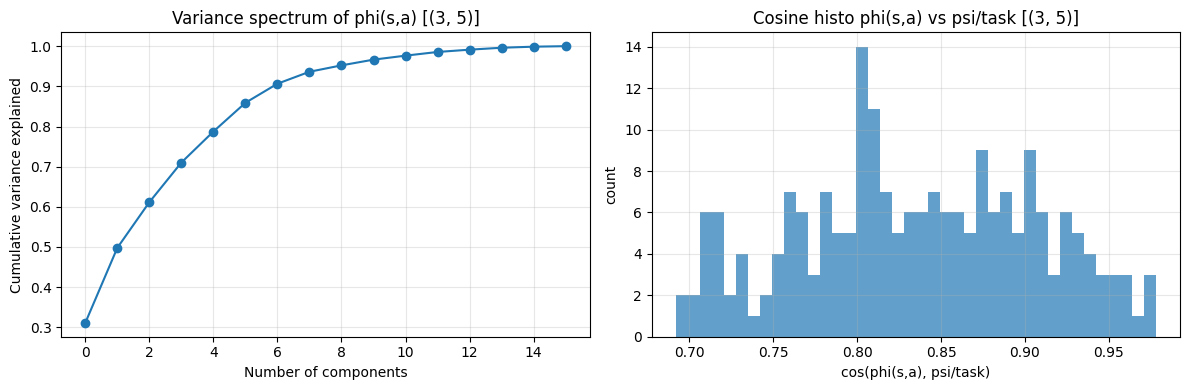


Goal embedding cosine similarity matrix:
     task_0     task_1     task_2     task_3     task_4     task_5     task_6     task_7     task_8     task_9    task_10    task_11
  task_0      1.000      0.954      0.911      0.687      0.811      0.801      0.791      0.827      0.769      0.769      0.755      0.694
  task_1      0.954      1.000      0.890      0.721      0.850      0.811      0.814      0.832      0.819      0.776      0.801      0.737
  task_2      0.911      0.890      1.000      0.815      0.779      0.867      0.860      0.858      0.747      0.775      0.775      0.674
  task_3      0.687      0.721      0.815      1.000      0.554      0.632      0.871      0.686      0.630      0.568      0.767      0.431
  task_4      0.811      0.850      0.779      0.554      1.000      0.892      0.803      0.900      0.968      0.911      0.901      0.910
  task_5      0.801      0.811      0.867      0.632      0.892      1.000      0.841      0.968      0.860      0.956  

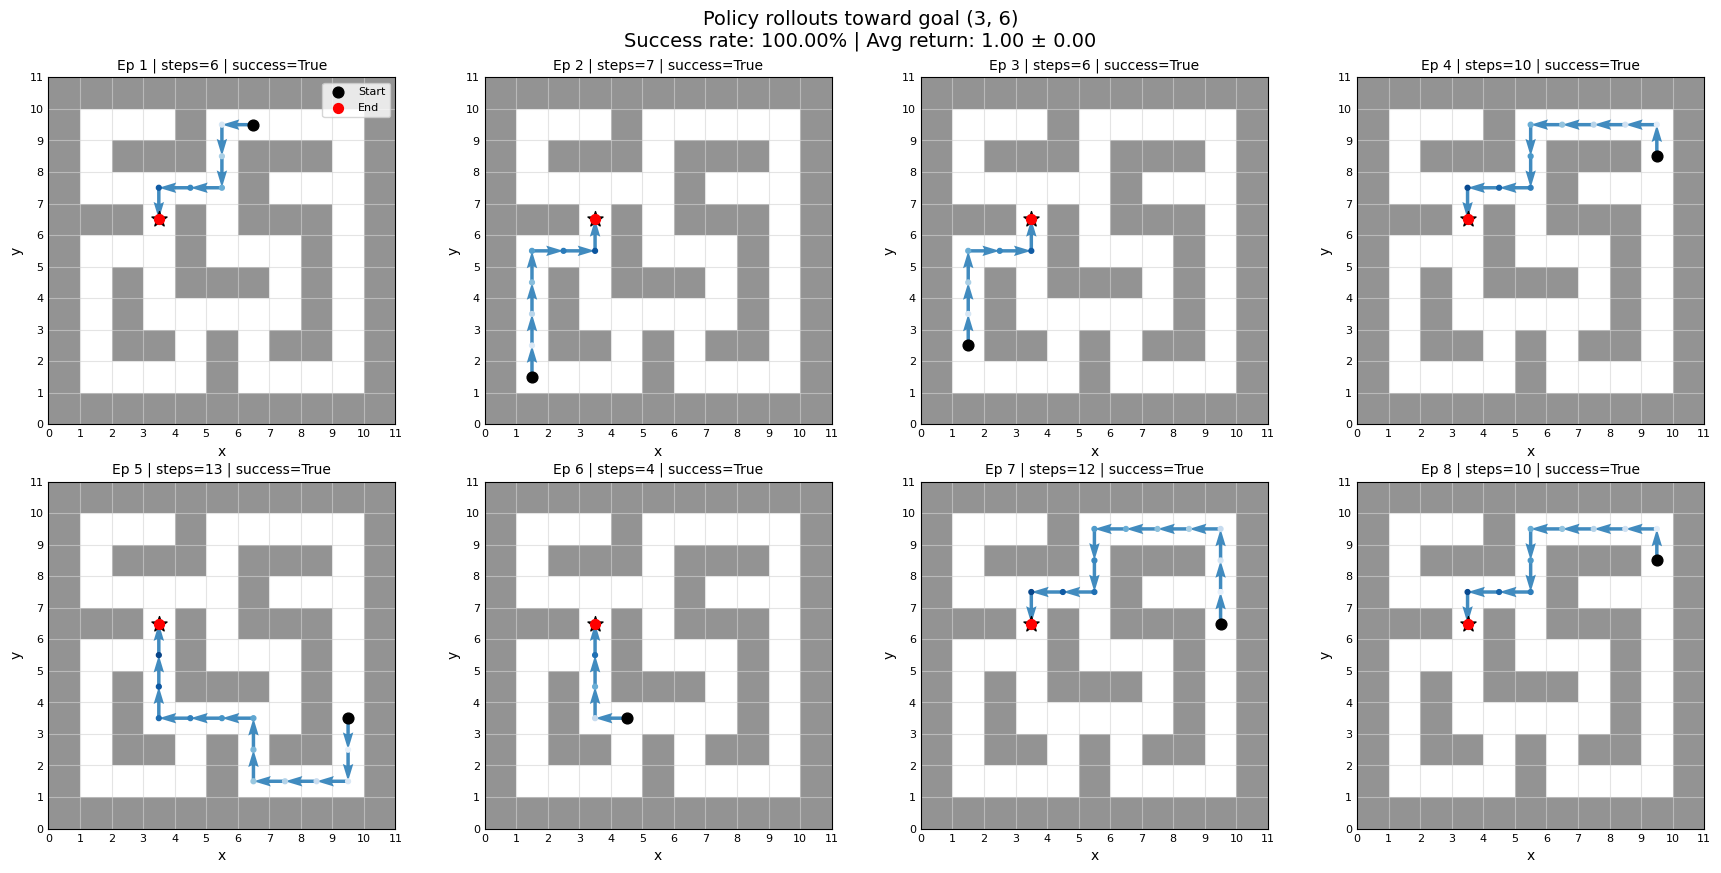

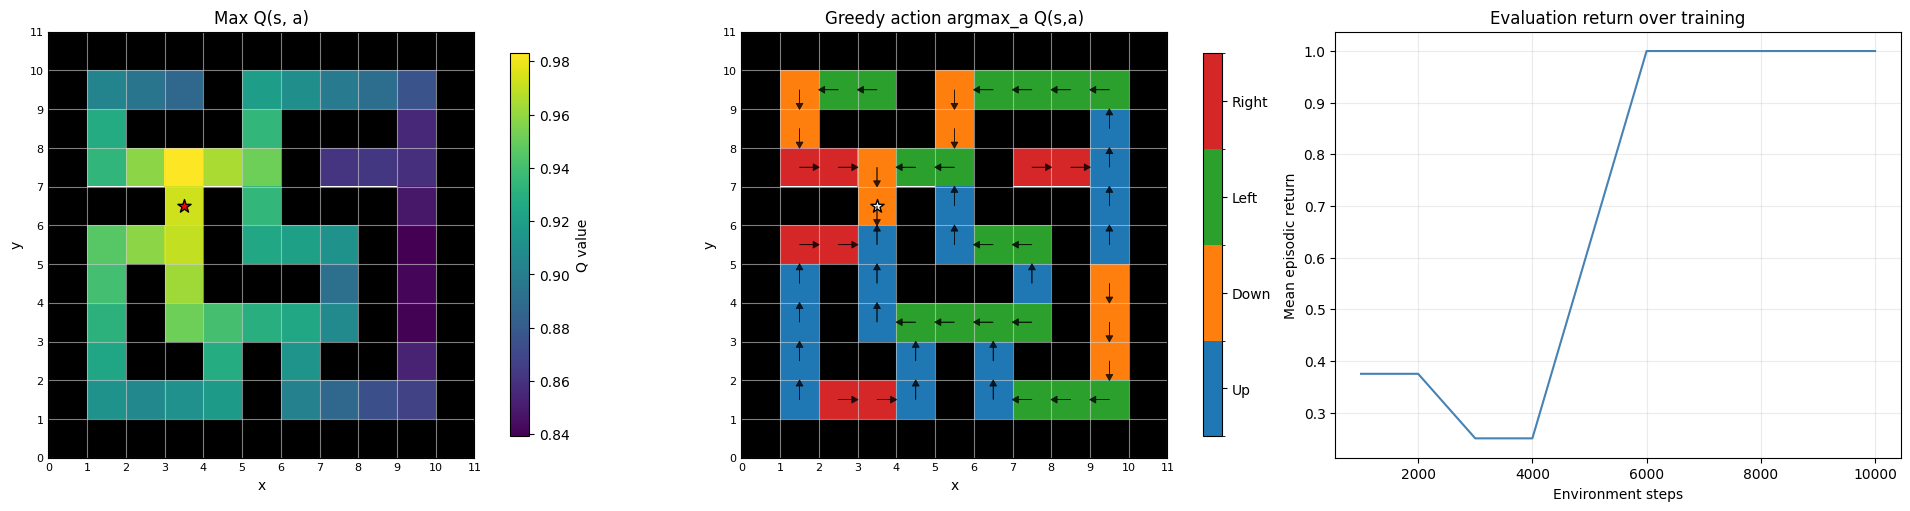

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 16)
psi(z) / task code base: (1, 16)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [3.834222  2.9257162 2.4002845 2.1615841 2.0885208]
cumulative variance (first 5 dims): [0.30360785 0.4803837  0.5993664  0.695861   0.78594255]
cos(phi(s,a), psi/task): mean=0.8549, std=0.0620


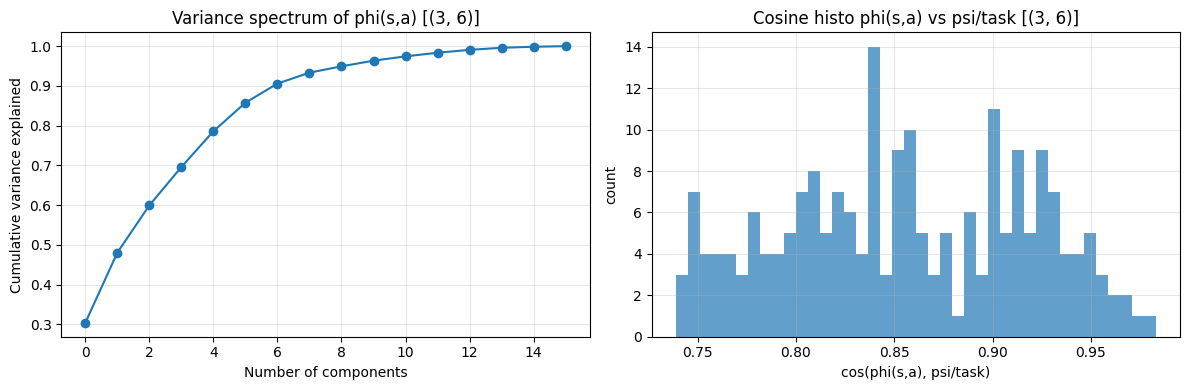


Goal embedding cosine similarity matrix:
     task_0     task_1     task_2     task_3     task_4     task_5     task_6     task_7     task_8     task_9    task_10    task_11    task_12
  task_0      1.000      0.954      0.911      0.687      0.811      0.801      0.791      0.827      0.769      0.769      0.755      0.694      0.723
  task_1      0.954      1.000      0.890      0.721      0.850      0.811      0.814      0.832      0.819      0.776      0.801      0.737      0.762
  task_2      0.911      0.890      1.000      0.815      0.779      0.867      0.860      0.858      0.747      0.775      0.775      0.674      0.710
  task_3      0.687      0.721      0.815      1.000      0.554      0.632      0.871      0.686      0.630      0.568      0.767      0.431      0.502
  task_4      0.811      0.850      0.779      0.554      1.000      0.892      0.803      0.900      0.968      0.911      0.901      0.910      0.929
  task_5      0.801      0.811      0.867      0.632  

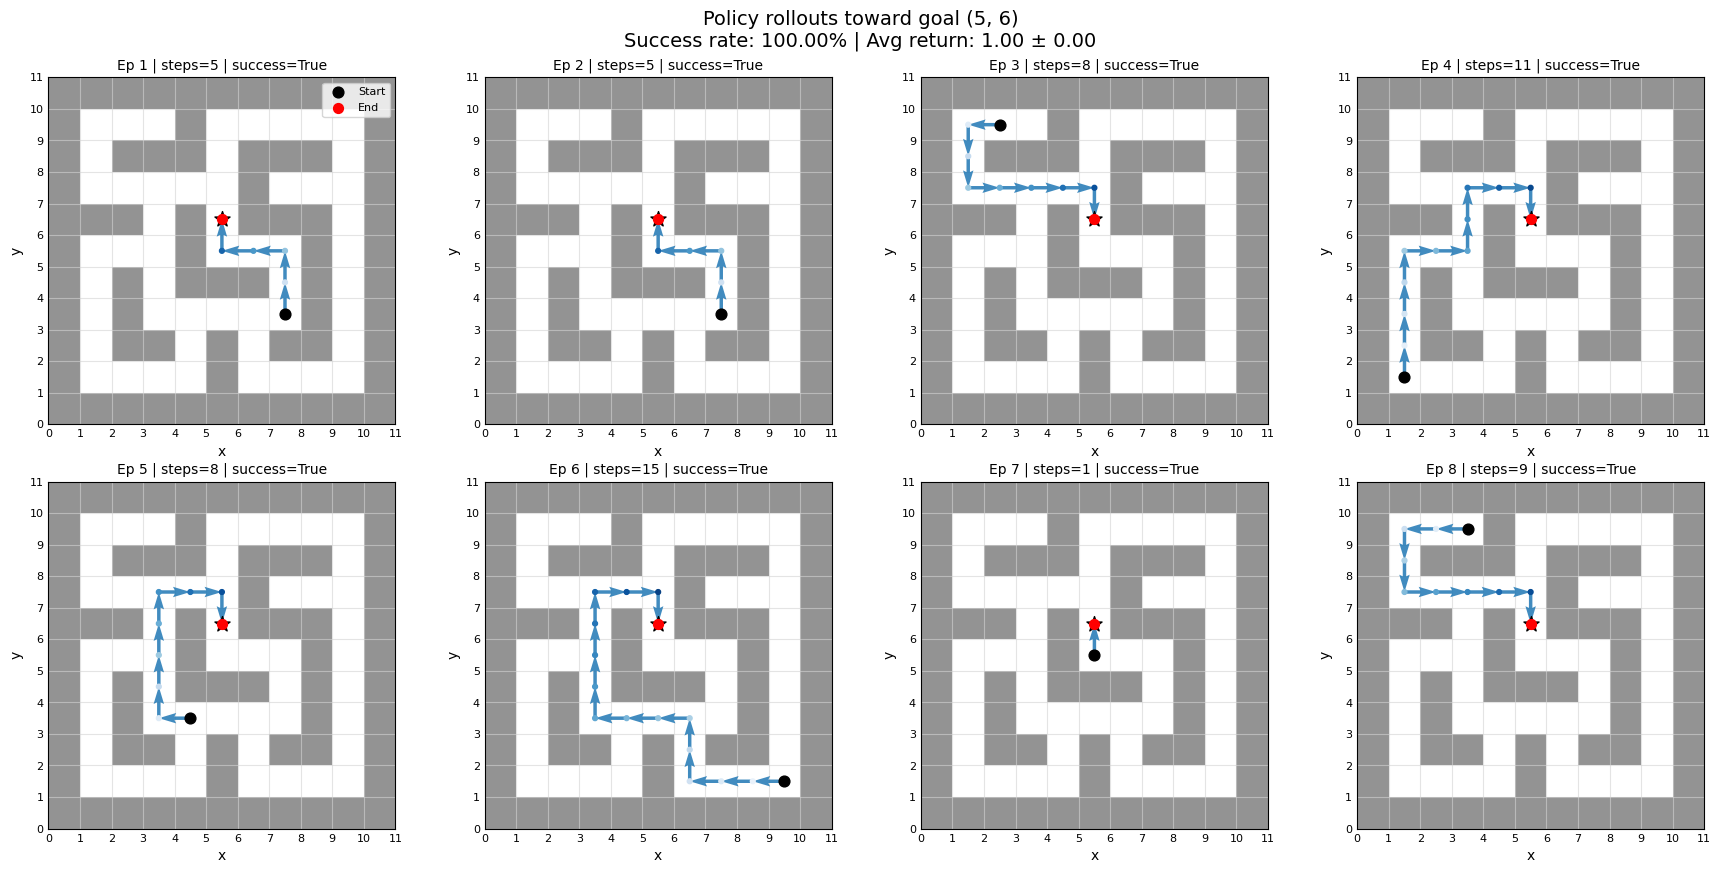

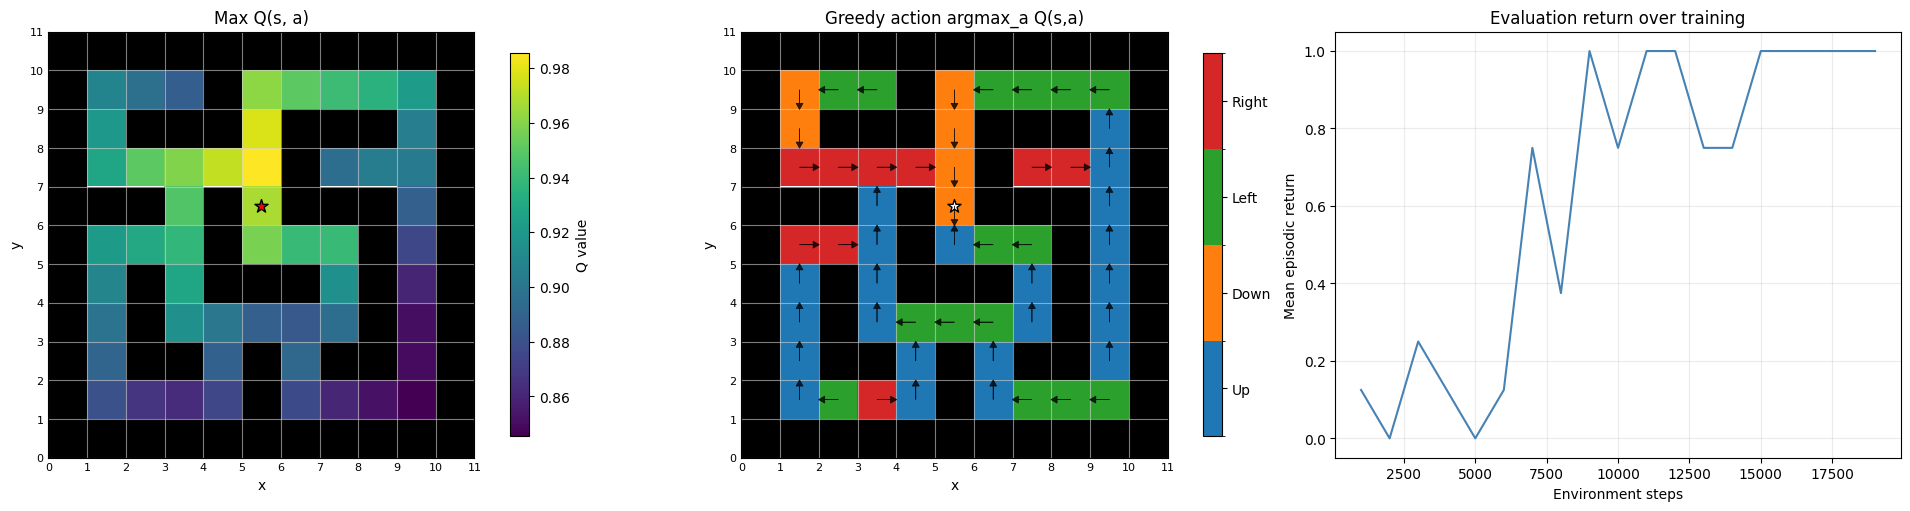

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 16)
psi(z) / task code base: (1, 16)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [3.8673754 2.8897395 2.5091732 2.2508774 2.0562088]
cumulative variance (first 5 dims): [0.30342066 0.47282708 0.6005514  0.7033332  0.7891055 ]
cos(phi(s,a), psi/task): mean=0.8527, std=0.0618


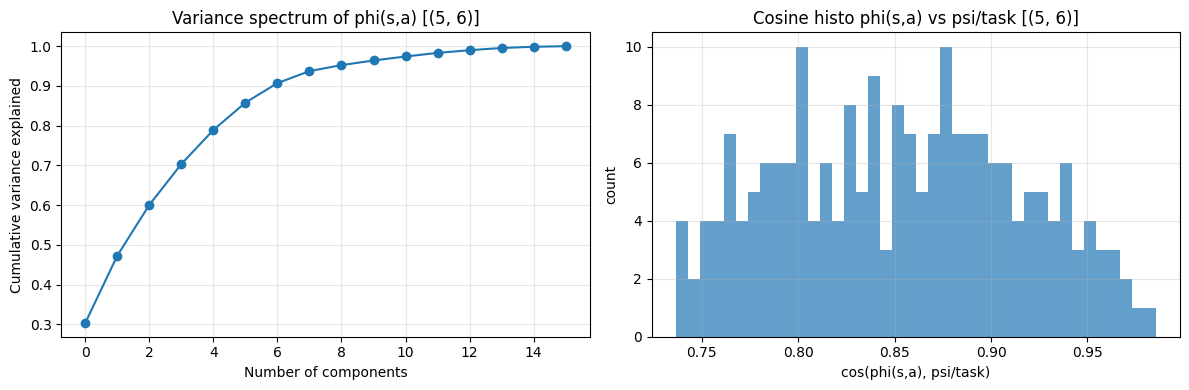


Goal embedding cosine similarity matrix:
     task_0     task_1     task_2     task_3     task_4     task_5     task_6     task_7     task_8     task_9    task_10    task_11    task_12    task_13
  task_0      1.000      0.954      0.911      0.687      0.811      0.801      0.791      0.827      0.769      0.769      0.755      0.694      0.723      0.762
  task_1      0.954      1.000      0.890      0.721      0.850      0.811      0.814      0.832      0.819      0.776      0.801      0.737      0.762      0.782
  task_2      0.911      0.890      1.000      0.815      0.779      0.867      0.860      0.858      0.747      0.775      0.775      0.674      0.710      0.761
  task_3      0.687      0.721      0.815      1.000      0.554      0.632      0.871      0.686      0.630      0.568      0.767      0.431      0.502      0.574
  task_4      0.811      0.850      0.779      0.554      1.000      0.892      0.803      0.900      0.968      0.911      0.901      0.910      0.929

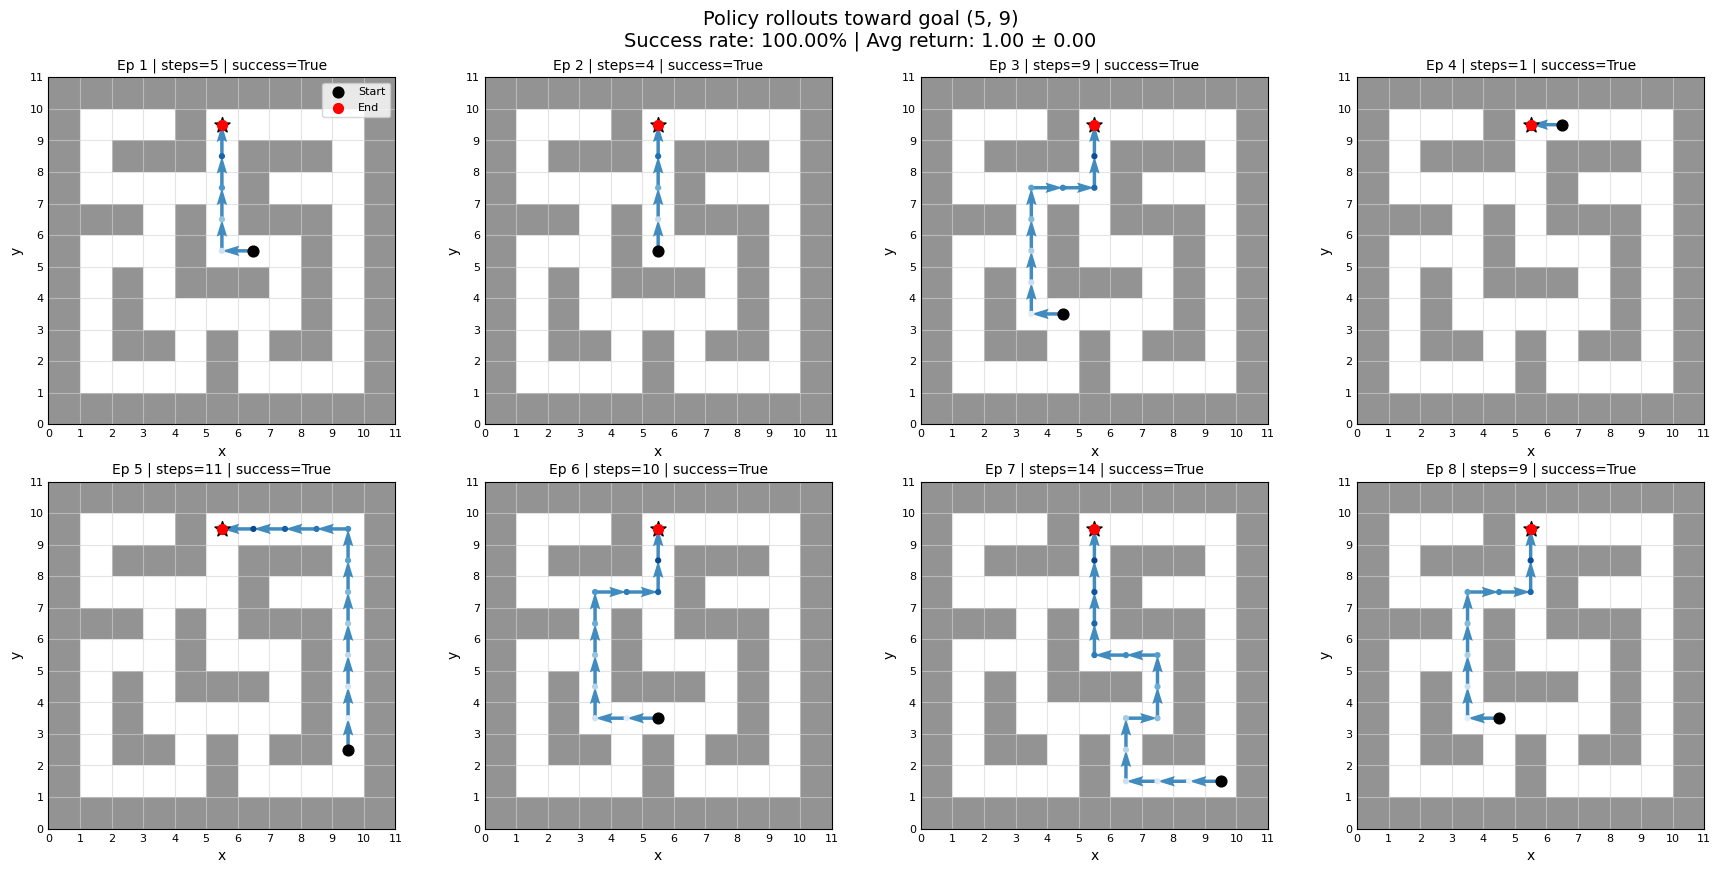

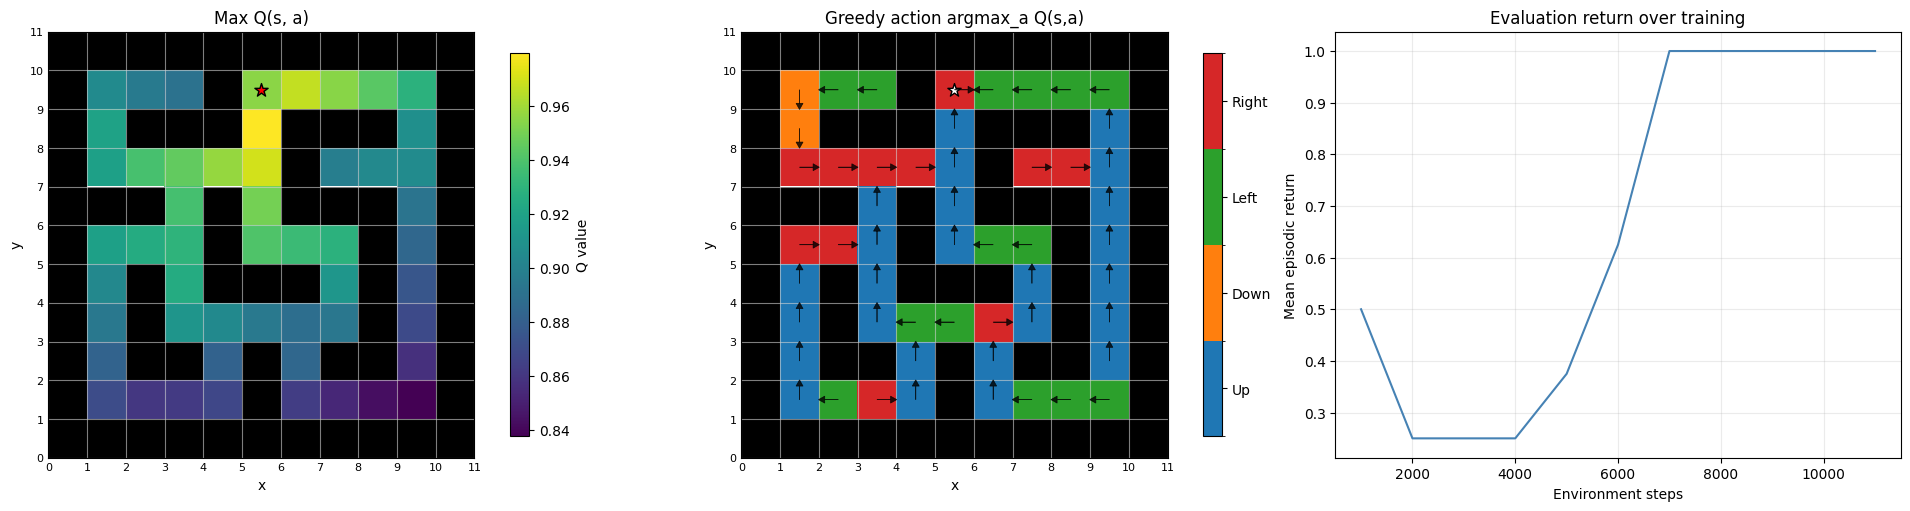

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 16)
psi(z) / task code base: (1, 16)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [3.9004104 2.9203246 2.413045  2.1516075 1.9973228]
cumulative variance (first 5 dims): [0.31081435 0.4850523  0.6040151  0.6985967  0.78010035]
cos(phi(s,a), psi/task): mean=0.8499, std=0.0618


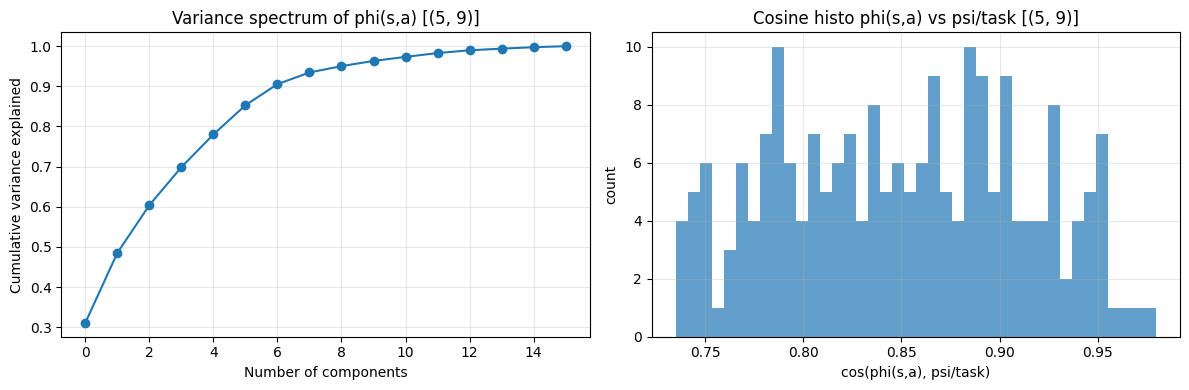


Goal embedding cosine similarity matrix:
     task_0     task_1     task_2     task_3     task_4     task_5     task_6     task_7     task_8     task_9    task_10    task_11    task_12    task_13    task_14
  task_0      1.000      0.954      0.911      0.687      0.811      0.801      0.791      0.827      0.769      0.769      0.755      0.694      0.723      0.762      0.731
  task_1      0.954      1.000      0.890      0.721      0.850      0.811      0.814      0.832      0.819      0.776      0.801      0.737      0.762      0.782      0.754
  task_2      0.911      0.890      1.000      0.815      0.779      0.867      0.860      0.858      0.747      0.775      0.775      0.674      0.710      0.761      0.736
  task_3      0.687      0.721      0.815      1.000      0.554      0.632      0.871      0.686      0.630      0.568      0.767      0.431      0.502      0.574      0.582
  task_4      0.811      0.850      0.779      0.554      1.000      0.892      0.803      0.900

In [15]:
SEEDS = [42]
# GOALS = [(9, 9), (7, 7), (3, 5), (3, 9), (5, 5), (3,6), (9,1), (1,1), (7,4), (9,8),(9,7)]

NUM_GOALS = 15

BUFFER_CAPACITY = 100000
LR = float(1e-3)
REG_ALPHA = 0.1

sa_keywords_local = ["sa_encoder"]
goal_keywords_local = ["goal_encoder"]

overall_results = {
    task_idx: {
        "goals_by_seed": {},
        "eval_returns": [],
        "eval_returns_time": [],
        "min_steps": [],
        "min_time": [],
        "task_embeddings": [],
        "sa_embeddings": [],
        "sa_fixed_probe_embeddings": [],
        "sa_batches_final": [],
        "sa_weight_change": [],
        "goal_weight_change": [],
    }
    for task_idx in range(NUM_GOALS)
}


# Store the actual physical goal associated with each
# seed/task-index pair.
goals_by_seed = {}
final_q_networks = {}
final_q_target_networks = {}
weight_history_by_seed = {}
seed_task_memories = {}
seed_retrieval_histories = {}


free_cells = get_free_cells(MAZE_LAYOUT)

for seed in SEEDS:
    print(f"\n================ SEED {seed} ================\n")
    set_seed(seed)


    goal_rng = np.random.default_rng(seed)

    GOALS = sample_goals(
        NUM_GOALS,
        goal_rng,
        cells=free_cells,
    )

    # Save this seed's task-index-to-goal mapping
    goals_by_seed[seed] = list(GOALS)

    for task_idx, goal in enumerate(GOALS):
        overall_results[task_idx]["goals_by_seed"][seed] = goal

    print(f"Sampled GOALS for seed {seed}: {GOALS}")

    env_tmp = make_env(goal=GOALS[0])
    obs_dim = env_tmp.observation_space.shape[0]
    num_actions = env_tmp.action_space.n
    env_tmp.close()

    q_net_base = FactorisedDQN_QNetwork(
        obs_dim=obs_dim,
        num_actions=num_actions,
        goal_dim=2,
        hidden_dim=64,
        rep_dim=16,
    ).to(DEVICE)

    q_target_base = FactorisedDQN_QNetwork(
        obs_dim=obs_dim,
        num_actions=num_actions,
        goal_dim=2,
        hidden_dim=64,
        rep_dim=16,
    ).to(DEVICE)

    q_target_base.load_state_dict(q_net_base.state_dict())

    for p in q_net_base.parameters():
        p.requires_grad_(True)

    for p in q_target_base.parameters():
        p.requires_grad_(False)

    # Existing SA-stability memory.
    embedding_memory = {
        "sa_anchors": [],
    }

    # New structured goal/task memory.
    task_memory = []

    # Existing lists used by plotting functions.
    task_embedding_memory = []
    task_replay_memories = {}
    task_labels = []

    # Retrieval diagnostics.
    retrieval_history = []

    # Weight snapshots.
    weight_history = []

    for task_idx, goal in enumerate(GOALS):
        task_label = f"task_{task_idx}"

        print(
            f"\n----- seed={seed}, task_idx={task_idx}, "
            f"goal={goal} -----\n"
        )

        for p in q_net_base.parameters():
            p.requires_grad_(True)

        weight_history.append(
            collect_weight_snapshot(
                qnet=q_net_base,
                goal_label=task_label,
                stage_label=f"goal_{task_label}_before_train",
                sa_keywords_local=sa_keywords_local,
                goal_keywords_local=goal_keywords_local,
                max_samples_per_group=40000,
            )
        )

        idx_to_goal = {i: g for i, g in enumerate(GOALS)}

        previous_task_buffers = {
            idx_to_goal[g_idx]: b
            for g_idx, b in task_replay_memories.items()
            if idx_to_goal[g_idx] != goal
        }

        current_regulariser = None #if len(task_embedding_memory) == 0 else "goal_memory_contrastive"

        (
            q_network,
            q_target_network,
            eval_returns,
            min_steps,
            min_time,
            task_embedding,
            sa_embedding_mean,
            sa_embedding_fixed,
            sa_batch_final,
            buffer,
        ) = dqn_train_multi_loss(
            seed=seed,
            q_network=q_net_base,
            q_target_network=q_target_base,
            env=make_env(goal=goal),
            obs_dim=obs_dim,
            buffer_capacity=BUFFER_CAPACITY,
            lr_sa=0.5 * LR,
            lr_goal=LR,
            goal=goal,
            device=DEVICE,
            embedding_memory=task_embedding_memory,
            memory_goals=GOALS,
            regulariser=current_regulariser,
            reg_alpha=REG_ALPHA,
            params=None,
            reference_params=None,
            fisher_diag=None,
            sa_reg_prefix_filter="sa_encoder",
            make_env=make_env,
            replay_task_buffers=previous_task_buffers,
            replay_ratio=1.0,
            replay_tasks_per_batch=task_idx+1,
            replay_loss_coef=1.0,
        )

        weight_history.append(
            collect_weight_snapshot(
                qnet=q_network,
                goal_label=goal,
                stage_label=f"{task_idx}_after_train",
                sa_keywords_local=sa_keywords_local,
                goal_keywords_local=goal_keywords_local,
                max_samples_per_group=40000,
            )
        )


        visualise_q_table(goal, q_network, eval_returns=eval_returns, device=DEVICE, make_env=make_env)
        visualise_embeddings(goal, q_network, device=DEVICE, make_env=make_env)


        final_task_embedding = np.asarray(
            task_embedding,
            dtype=np.float32,
        ).copy()
        task_embedding_memory.append(final_task_embedding)
        task_labels.append(task_label)

        print_goal_embedding_similarity(
            task_embedding_memory,
            goal_labels=task_labels,
        )


        # current_reference = snapshot_named_parameters(q_network, prefix_filter="sa_encoder")
        # current_fisher = estimate_fisher_diag(
        #     model=q_network,
        #     target_model=q_target_network,
        #     replay_buffer=buffer,
        #     goal=goal,
        #     num_actions=num_actions,
        #     device=DEVICE,
        #     gamma=0.99,
        #     batch_size=256,
        #     n_batches=64,
        #     prefix_filter="sa_encoder",
        # )

        # if cumulative_fisher is None:
        #     cumulative_fisher = current_fisher
        # else:
        #     for name, F_t in current_fisher.items():
        #         if name in cumulative_fisher:
        #             cumulative_fisher[name] = cumulative_fisher[name] + F_t
        #         else:
        #             cumulative_fisher[name] = F_t.clone()

        # prev_reference_params = current_reference
        prev_q_net = deepcopy(q_network)
        prev_q_target = deepcopy(q_target_network)

        # store this goal buffer for future replay
        task_replay_memories[task_idx] = buffer

        overall_results[task_idx]["eval_returns"].append(eval_returns)
        overall_results[task_idx]["min_steps"].append(min_steps)
        overall_results[task_idx]["min_time"].append(min_time)
        overall_results[task_idx]["task_embeddings"].append(task_embedding)
        overall_results[task_idx]["sa_embeddings"].append(sa_embedding_mean)
        overall_results[task_idx]["sa_fixed_probe_embeddings"].append(sa_embedding_fixed)
        overall_results[task_idx]["sa_batches_final"].append(sa_batch_final)

    # ========================================================
    # SAVE SEED-LEVEL OBJECTS
    # ========================================================

    final_q_networks[seed] = deepcopy(q_network).eval()
    final_q_target_networks[seed] = deepcopy(q_target_network).eval()
    weight_history_by_seed[seed] = deepcopy(weight_history)
    seed_task_memories[seed] = deepcopy(task_memory)
    seed_retrieval_histories[seed] = deepcopy(retrieval_history)

    print(
        f"\nSaved final networks and task memory "
        f"for seed {seed}."
    )

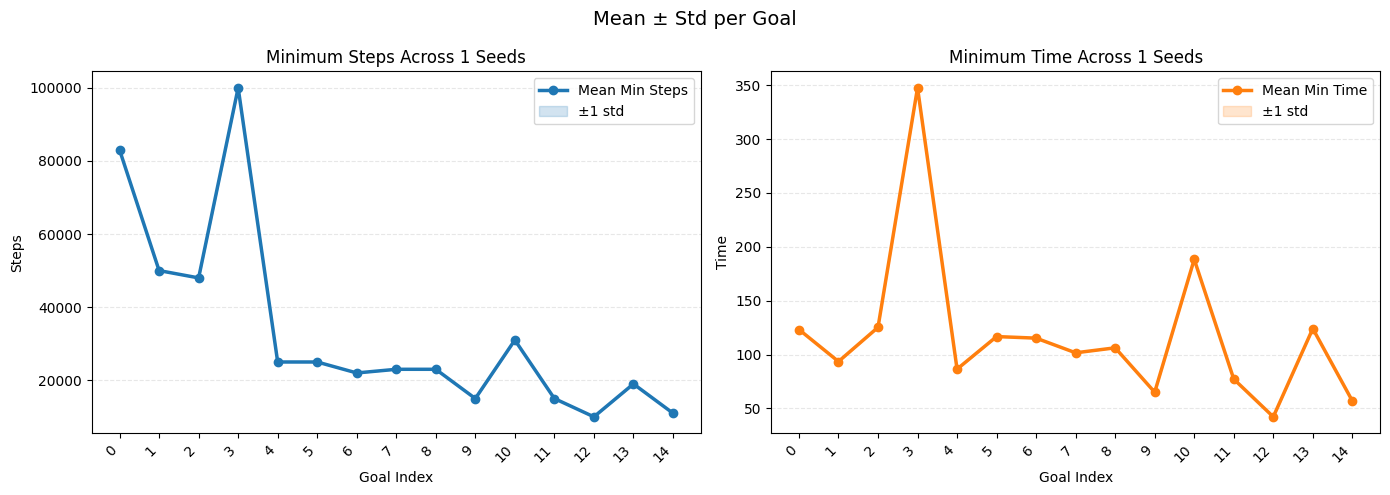

In [16]:
plot_min_steps_and_min_time(overall_results=overall_results, seeds=SEEDS)

In [17]:
def evaluate_zero_shot_goal(
    q_network,
    goal,
    make_env,
    device,
    episodes=8,
):
    q_network.eval()

    eval_env = make_env(goal=goal)

    goal_arr = np.asarray(
        goal,
        dtype=np.float32,
    )

    goal_t = torch.tensor(
        goal_arr,
        dtype=torch.float32,
        device=device,
    ).unsqueeze(0)

    def eval_policy(obs):
        obs_t = torch.tensor(
            obs,
            dtype=torch.float32,
            device=device,
        ).unsqueeze(0)

        with torch.inference_mode():
            q_values = q_network.q_val_for_argmax_action(
                obs_t,
                goal_t,
            )

        return int(
            q_values.argmax(
                dim=-1,
            ).item()
        )

    mean_return, mean_length = evaluate_policy(
        eval_env,
        eval_policy,
        episodes=episodes,
    )

    eval_env.close()

    return mean_return, mean_length


# Check that seed-specific goals were saved
if "goals_by_seed" not in globals():
    raise RuntimeError(
        "goals_by_seed does not exist. "
        "Add goals_by_seed = {} before the training loop and "
        "goals_by_seed[seed] = list(GOALS) after sampling goals."
    )


# Store zero-shot results using task_idx rather than goal coordinates
zero_shot_returns = {
    seed: {
        task_idx: None
        for task_idx in range(NUM_GOALS)
    }
    for seed in SEEDS
}

zero_shot_lengths = {
    seed: {
        task_idx: None
        for task_idx in range(NUM_GOALS)
    }
    for seed in SEEDS
}


# Evaluate each final network on the goals sampled for its own seed
for seed in SEEDS:
    print(
        f"\n========== ZERO-SHOT EVALUATION "
        f"SEED {seed} ==========\n"
    )

    q_final = final_q_networks[seed]

    # These are the goals generated for this particular seed
    seed_goals = goals_by_seed[seed]

    if len(seed_goals) != NUM_GOALS:
        raise ValueError(
            f"Seed {seed} has {len(seed_goals)} goals, "
            f"but NUM_GOALS={NUM_GOALS}."
        )

    for task_idx, test_goal in enumerate(seed_goals):
        mean_return, mean_length = evaluate_zero_shot_goal(
            q_network=q_final,
            goal=test_goal,
            make_env=make_env,
            device=DEVICE,
            episodes=8,
        )

        zero_shot_returns[seed][task_idx] = mean_return
        zero_shot_lengths[seed][task_idx] = mean_length

        print(
            f"task_idx={task_idx} | "
            f"goal={test_goal} | "
            f"return={mean_return:.3f} | "
            f"length={mean_length:.1f}"
        )


# Aggregate zero-shot results across seeds by task index
zero_shot_return_mean = {}
zero_shot_return_std = {}
zero_shot_length_mean = {}
zero_shot_length_std = {}

for task_idx in range(NUM_GOALS):
    return_values = [
        zero_shot_returns[seed][task_idx]
        for seed in SEEDS
    ]

    length_values = [
        zero_shot_lengths[seed][task_idx]
        for seed in SEEDS
    ]

    zero_shot_return_mean[task_idx] = float(
        np.mean(return_values)
    )

    zero_shot_return_std[task_idx] = float(
        np.std(return_values)
    )

    zero_shot_length_mean[task_idx] = float(
        np.mean(length_values)
    )

    zero_shot_length_std[task_idx] = float(
        np.std(length_values)
    )


# Print final task-index-based results
print(
    "\n========== FINAL ZERO-SHOT RESULTS "
    "BY TASK INDEX ==========\n"
)

for task_idx in range(NUM_GOALS):
    print(
        f"task_idx={task_idx} | "
        f"return="
        f"{zero_shot_return_mean[task_idx]:.3f} "
        f"+/- "
        f"{zero_shot_return_std[task_idx]:.3f} | "
        f"length="
        f"{zero_shot_length_mean[task_idx]:.1f} "
        f"+/- "
        f"{zero_shot_length_std[task_idx]:.1f}"
    )


# Optional diagnostic: show which physical goal each task_idx represented
print(
    "\n========== TASK INDEX TO GOAL MAPPING ==========\n"
)

for task_idx in range(NUM_GOALS):
    task_goal_mapping = {
        seed: goals_by_seed[seed][task_idx]
        for seed in SEEDS
    }

    print(
        f"task_idx={task_idx} | "
        f"goals_by_seed={task_goal_mapping}"
    )


========== ZERO-SHOT EVALUATION SEED 42 ==========

task_idx=0 | goal=(4, 1) | return=0.375 | length=65.0
task_idx=1 | goal=(6, 1) | return=1.000 | length=5.5
task_idx=2 | goal=(5, 5) | return=0.750 | length=29.0
task_idx=3 | goal=(7, 7) | return=0.000 | length=100.0
task_idx=4 | goal=(4, 2) | return=0.500 | length=51.8
task_idx=5 | goal=(5, 7) | return=0.375 | length=65.2
task_idx=6 | goal=(9, 8) | return=0.500 | length=52.9
task_idx=7 | goal=(7, 9) | return=0.750 | length=32.4
task_idx=8 | goal=(7, 3) | return=0.875 | length=17.4
task_idx=9 | goal=(4, 7) | return=0.125 | length=88.6
task_idx=10 | goal=(9, 3) | return=0.000 | length=100.0
task_idx=11 | goal=(3, 5) | return=0.375 | length=63.4
task_idx=12 | goal=(3, 6) | return=0.250 | length=76.4
task_idx=13 | goal=(5, 6) | return=1.000 | length=6.4
task_idx=14 | goal=(5, 9) | return=1.000 | length=7.2

========== FINAL ZERO-SHOT RESULTS BY TASK INDEX ==========

task_idx=0 | return=0.375 +/- 0.000 | length=65.0 +/- 0.0
task_idx=1 | 


========== CONTINUAL LEARNING METRICS BY TASK INDEX ==========

Task 0 | initial=1.000 +/- 0.000 | final zero-shot=0.375 +/- 0.000 | forgetting=0.625 +/- 0.000 | BWT=-0.625 +/- 0.000 | retention=0.375 +/- 0.000
Task 1 | initial=1.000 +/- 0.000 | final zero-shot=1.000 +/- 0.000 | forgetting=0.000 +/- 0.000 | BWT=0.000 +/- 0.000 | retention=1.000 +/- 0.000
Task 2 | initial=1.000 +/- 0.000 | final zero-shot=0.750 +/- 0.000 | forgetting=0.250 +/- 0.000 | BWT=-0.250 +/- 0.000 | retention=0.750 +/- 0.000
Task 3 | initial=0.750 +/- 0.000 | final zero-shot=0.000 +/- 0.000 | forgetting=0.750 +/- 0.000 | BWT=-0.750 +/- 0.000 | retention=0.000 +/- 0.000
Task 4 | initial=1.000 +/- 0.000 | final zero-shot=0.500 +/- 0.000 | forgetting=0.500 +/- 0.000 | BWT=-0.500 +/- 0.000 | retention=0.500 +/- 0.000
Task 5 | initial=1.000 +/- 0.000 | final zero-shot=0.375 +/- 0.000 | forgetting=0.625 +/- 0.000 | BWT=-0.625 +/- 0.000 | retention=0.375 +/- 0.000
Task 6 | initial=1.000 +/- 0.000 | final zero-shot=0.5

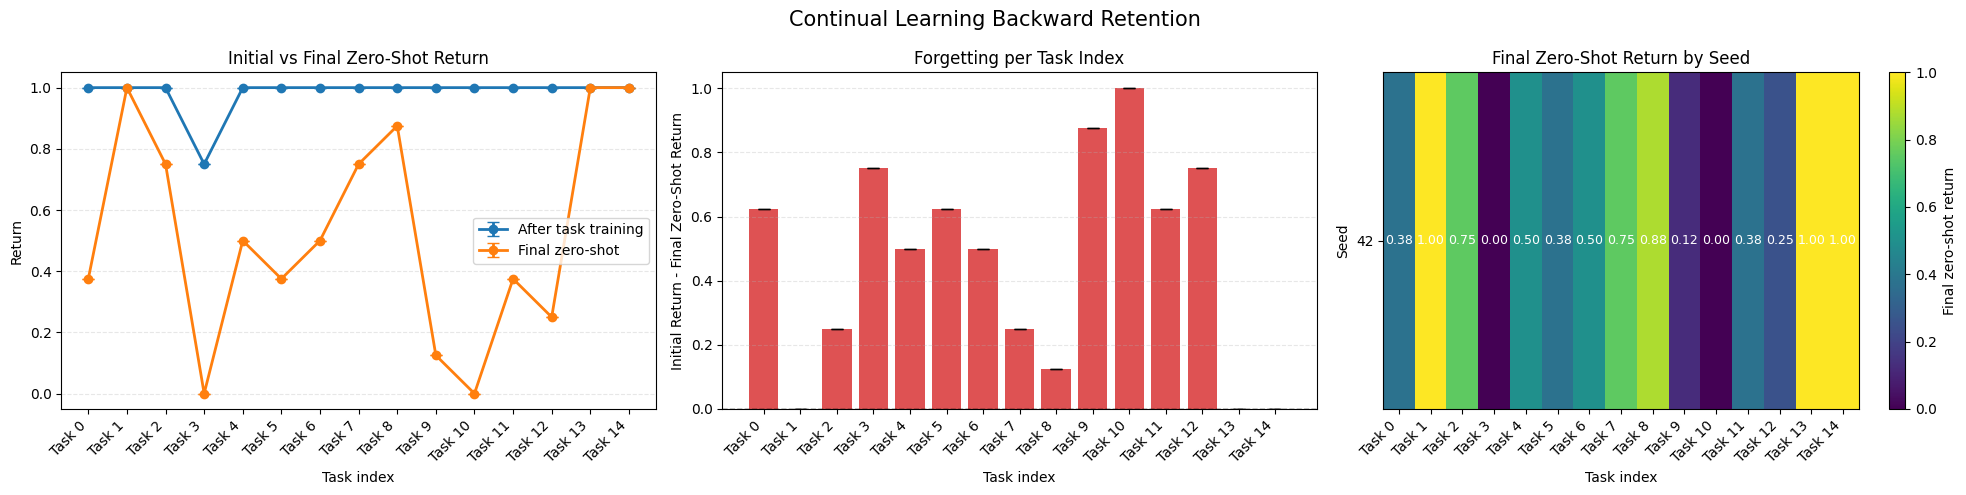

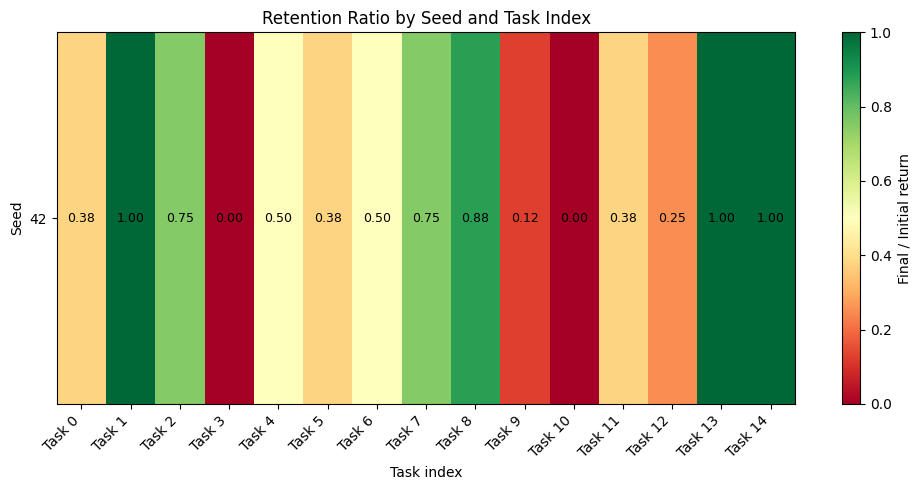

In [18]:
def extract_initial_return(eval_history):
    if len(eval_history) == 0:
        return np.nan

    last_entry = eval_history[-1]

    if isinstance(
        last_entry,
        (tuple, list, np.ndarray),
    ):
        return float(last_entry[1])

    return float(last_entry)


num_seeds = len(SEEDS)
num_tasks = NUM_GOALS


# ------------------------------------------------------------
# Allocate matrices
# Rows    = seeds
# Columns = task indices
# ------------------------------------------------------------
initial_matrix = np.full(
    (num_seeds, num_tasks),
    np.nan,
    dtype=np.float32,
)

final_zero_shot_matrix = np.full(
    (num_seeds, num_tasks),
    np.nan,
    dtype=np.float32,
)


# ------------------------------------------------------------
# Fill initial and final zero-shot matrices
# ------------------------------------------------------------
for seed_idx, seed in enumerate(SEEDS):
    for task_idx in range(num_tasks):

        # Initial return after training this task.
        # Results were appended in SEEDS order during training.
        eval_history = (
            overall_results[task_idx][
                "eval_returns"
            ][seed_idx]
        )

        initial_matrix[
            seed_idx,
            task_idx,
        ] = extract_initial_return(
            eval_history
        )

        # Final zero-shot return for this seed/task pair
        final_zero_shot_matrix[
            seed_idx,
            task_idx,
        ] = zero_shot_returns[
            seed
        ][
            task_idx
        ]


# ------------------------------------------------------------
# Continual-learning metrics
# ------------------------------------------------------------
forgetting_matrix = (
    initial_matrix
    - final_zero_shot_matrix
)

backward_transfer_matrix = (
    final_zero_shot_matrix
    - initial_matrix
)


# Use a safe division operation for retention.
# This avoids division by zero when the initial return is zero.
retention_matrix = np.divide(
    final_zero_shot_matrix,
    initial_matrix,
    out=np.full_like(
        final_zero_shot_matrix,
        np.nan,
    ),
    where=np.abs(initial_matrix) > 1e-8,
)


# ------------------------------------------------------------
# Aggregate metrics across seeds
# ------------------------------------------------------------
initial_mean = np.nanmean(
    initial_matrix,
    axis=0,
)

initial_std = np.nanstd(
    initial_matrix,
    axis=0,
)

final_mean = np.nanmean(
    final_zero_shot_matrix,
    axis=0,
)

final_std = np.nanstd(
    final_zero_shot_matrix,
    axis=0,
)

forgetting_mean = np.nanmean(
    forgetting_matrix,
    axis=0,
)

forgetting_std = np.nanstd(
    forgetting_matrix,
    axis=0,
)

bwt_mean = np.nanmean(
    backward_transfer_matrix,
    axis=0,
)

bwt_std = np.nanstd(
    backward_transfer_matrix,
    axis=0,
)

retention_mean = np.nanmean(
    retention_matrix,
    axis=0,
)

retention_std = np.nanstd(
    retention_matrix,
    axis=0,
)


# ------------------------------------------------------------
# Print per-task metrics
# ------------------------------------------------------------
print(
    "\n========== CONTINUAL LEARNING METRICS "
    "BY TASK INDEX ==========\n"
)

for task_idx in range(num_tasks):
    print(
        f"Task {task_idx} | "
        f"initial="
        f"{initial_mean[task_idx]:.3f} "
        f"+/- "
        f"{initial_std[task_idx]:.3f} | "
        f"final zero-shot="
        f"{final_mean[task_idx]:.3f} "
        f"+/- "
        f"{final_std[task_idx]:.3f} | "
        f"forgetting="
        f"{forgetting_mean[task_idx]:.3f} "
        f"+/- "
        f"{forgetting_std[task_idx]:.3f} | "
        f"BWT="
        f"{bwt_mean[task_idx]:.3f} "
        f"+/- "
        f"{bwt_std[task_idx]:.3f} | "
        f"retention="
        f"{retention_mean[task_idx]:.3f} "
        f"+/- "
        f"{retention_std[task_idx]:.3f}"
    )


# ------------------------------------------------------------
# Print overall metrics
# ------------------------------------------------------------
print(
    "\n========== OVERALL METRICS ==========\n"
)

print(
    f"Mean initial return: "
    f"{np.nanmean(initial_matrix):.3f}"
)

print(
    f"Mean final zero-shot return: "
    f"{np.nanmean(final_zero_shot_matrix):.3f}"
)

print(
    f"Mean forgetting: "
    f"{np.nanmean(forgetting_matrix):.3f}"
)

print(
    f"Mean backward transfer: "
    f"{np.nanmean(backward_transfer_matrix):.3f}"
)

print(
    f"Mean retention: "
    f"{np.nanmean(retention_matrix):.3f}"
)


# ------------------------------------------------------------
# Plot labels
# ------------------------------------------------------------
task_labels = [
    f"Task {task_idx}"
    for task_idx in range(num_tasks)
]

seed_labels = [
    str(seed)
    for seed in SEEDS
]

x = np.arange(num_tasks)


# ------------------------------------------------------------
# Main plots
# ------------------------------------------------------------
fig, axes = plt.subplots(
    1,
    3,
    figsize=(20, 5),
)


# ------------------------------------------------------------
# Initial versus final zero-shot return
# ------------------------------------------------------------
axes[0].errorbar(
    x,
    initial_mean,
    yerr=initial_std,
    marker="o",
    linewidth=2,
    capsize=4,
    label="After task training",
)

axes[0].errorbar(
    x,
    final_mean,
    yerr=final_std,
    marker="o",
    linewidth=2,
    capsize=4,
    label="Final zero-shot",
)

axes[0].set_title(
    "Initial vs Final Zero-Shot Return"
)

axes[0].set_xlabel(
    "Task index"
)

axes[0].set_ylabel(
    "Return"
)

axes[0].set_xticks(x)

axes[0].set_xticklabels(
    task_labels,
    rotation=45,
    ha="right",
)

axes[0].grid(
    True,
    axis="y",
    linestyle="--",
    alpha=0.3,
)

axes[0].legend()


# ------------------------------------------------------------
# Forgetting
# ------------------------------------------------------------
forgetting_colors = [
    "tab:red" if value > 0 else "tab:green"
    for value in forgetting_mean
]

axes[1].bar(
    x,
    forgetting_mean,
    yerr=forgetting_std,
    color=forgetting_colors,
    alpha=0.8,
    capsize=4,
)

axes[1].axhline(
    0.0,
    color="black",
    linestyle="--",
    linewidth=1,
)

axes[1].set_title(
    "Forgetting per Task Index"
)

axes[1].set_xlabel(
    "Task index"
)

axes[1].set_ylabel(
    "Initial Return - Final Zero-Shot Return"
)

axes[1].set_xticks(x)

axes[1].set_xticklabels(
    task_labels,
    rotation=45,
    ha="right",
)

axes[1].grid(
    True,
    axis="y",
    linestyle="--",
    alpha=0.3,
)


# ------------------------------------------------------------
# Final zero-shot heatmap across seeds
# ------------------------------------------------------------
im = axes[2].imshow(
    final_zero_shot_matrix,
    aspect="auto",
    cmap="viridis",
    vmin=0.0,
    vmax=1.0,
)

axes[2].set_title(
    "Final Zero-Shot Return by Seed"
)

axes[2].set_xlabel(
    "Task index"
)

axes[2].set_ylabel(
    "Seed"
)

axes[2].set_xticks(
    np.arange(num_tasks)
)

axes[2].set_xticklabels(
    task_labels,
    rotation=45,
    ha="right",
)

axes[2].set_yticks(
    np.arange(num_seeds)
)

axes[2].set_yticklabels(
    seed_labels
)


for seed_idx in range(num_seeds):
    for task_idx in range(num_tasks):
        value = final_zero_shot_matrix[
            seed_idx,
            task_idx,
        ]

        if np.isnan(value):
            text_value = "nan"
        else:
            text_value = f"{value:.2f}"

        axes[2].text(
            task_idx,
            seed_idx,
            text_value,
            ha="center",
            va="center",
            color="white",
            fontsize=9,
        )


fig.colorbar(
    im,
    ax=axes[2],
    label="Final zero-shot return",
)


fig.suptitle(
    "Continual Learning Backward Retention",
    fontsize=15,
)

fig.tight_layout()

plt.show()


# ------------------------------------------------------------
# Separate retention heatmap
# ------------------------------------------------------------
fig, ax = plt.subplots(
    figsize=(10, 5),
)


# Clip only for visualisation
retention_plot = np.clip(
    retention_matrix,
    0.0,
    1.0,
)


im = ax.imshow(
    retention_plot,
    aspect="auto",
    cmap="RdYlGn",
    vmin=0.0,
    vmax=1.0,
)

ax.set_title(
    "Retention Ratio by Seed and Task Index"
)

ax.set_xlabel(
    "Task index"
)

ax.set_ylabel(
    "Seed"
)

ax.set_xticks(
    np.arange(num_tasks)
)

ax.set_xticklabels(
    task_labels,
    rotation=45,
    ha="right",
)

ax.set_yticks(
    np.arange(num_seeds)
)

ax.set_yticklabels(
    seed_labels
)


for seed_idx in range(num_seeds):
    for task_idx in range(num_tasks):
        value = retention_matrix[
            seed_idx,
            task_idx,
        ]

        if np.isnan(value):
            text_value = "nan"
        else:
            text_value = f"{value:.2f}"

        ax.text(
            task_idx,
            seed_idx,
            text_value,
            ha="center",
            va="center",
            color="black",
            fontsize=9,
        )


fig.colorbar(
    im,
    ax=ax,
    label="Final / Initial return",
)

fig.tight_layout()

plt.show()

## New Goal Test. 
Random sample goals from free cells, and check the embeddings. No training. This is to check the Spatial knowledge on psi(g)

## Backward Tasks Fine-tuning
Because embeddings have changed, to successfully achieve the earlier tasks, fine-tuning is needed.


================ BACKWARD RETRAIN SEED 42 ================


----- backward retrain: seed=42, goal=(4, 1) -----

[DQN-factorised] step=   1000 | eps=0.981 | eval_return=0.625 | eval_len=41.2 | TD=0.000000 | ReplayTD=0.000000 | Ortho=0.000000 | SigReg=0.000000 | EWC=0.000000 | Loss=0.000000| goal_reg_loss=0.000000
[DQN-factorised] step=   2000 | eps=0.962 | eval_return=0.250 | eval_len=75.8 | TD=0.000000 | ReplayTD=0.000000 | Ortho=0.000000 | SigReg=0.000000 | EWC=0.000000 | Loss=0.000000| goal_reg_loss=0.000000
[DQN-factorised] step=   3000 | eps=0.943 | eval_return=0.375 | eval_len=64.2 | TD=0.000000 | ReplayTD=0.000000 | Ortho=0.000000 | SigReg=0.000000 | EWC=0.000000 | Loss=0.000000| goal_reg_loss=0.000000
[DQN-factorised] step=   4000 | eps=0.924 | eval_return=0.750 | eval_len=28.9 | TD=0.000000 | ReplayTD=0.000000 | Ortho=0.000000 | SigReg=0.000000 | EWC=0.000000 | Loss=0.000000| goal_reg_loss=0.000000
[DQN-factorised] step=   5000 | eps=0.905 | eval_return=0.625 | eval_len=40.6 

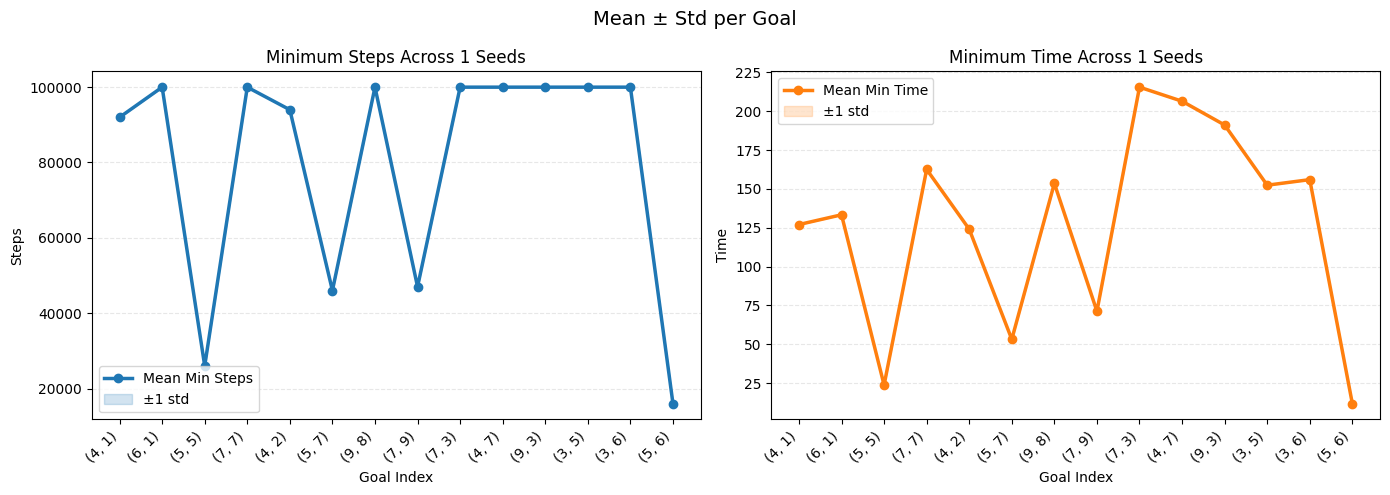


===== Backward retrain summary (freeze sa_encoder only) =====

Goal (4, 1): baseline_steps_mean=83000.0, retrain_steps_mean=92000.0, steps_ratio_mean=1.108433734939759, n=1
          baseline_time_mean=123.20964920899132, retrain_time_mean=127.07613050000509, time_ratio_mean=1.0313813188807586, n=1

Goal (6, 1): baseline_steps_mean=50000.0, retrain_steps_mean=100000.0, steps_ratio_mean=2.0, n=1
          baseline_time_mean=93.50179549999302, retrain_time_mean=133.35472374997335, time_ratio_mean=1.4262263418244552, n=1

Goal (5, 5): baseline_steps_mean=48000.0, retrain_steps_mean=26000.0, steps_ratio_mean=0.5416666666666666, n=1
          baseline_time_mean=125.22833045898005, retrain_time_mean=23.713930999976583, time_ratio_mean=0.18936554462605687, n=1

Goal (7, 7): baseline_steps_mean=100000.0, retrain_steps_mean=100000.0, steps_ratio_mean=1.0, n=1
          baseline_time_mean=347.5537433329737, retrain_time_mean=162.58326112502255, time_ratio_mean=0.4677931521205333, n=1

Goal (4, 

In [19]:
# =========================
# Backward Tasks Fine-tuning
# Retrain old goals starting from each seed's FINAL model
# Freeze phi = sa_encoder, retrain the rest
# =========================


RETRAIN_LR = 1e-3
RETRAIN_GOALS_MODE = "all"   # "early", "all", or "custom"
RETRAIN_NUM_EARLY = 3
RETRAIN_CUSTOM_GOALS = []    # only used if RETRAIN_GOALS_MODE == "custom"


def freeze_sa_encoder_only(model):
    for name, p in model.named_parameters():
        p.requires_grad_(True)
        if name.startswith("sa_encoder"):
            p.requires_grad_(False)

    trainable_params = [p for p in model.parameters() if p.requires_grad]

    if len(trainable_params) == 0:
        raise ValueError("No trainable params left after freezing sa_encoder.")

    return trainable_params


# Build mapping: seed -> goal -> task_idx
seed_goal_to_task_idx = {
    seed: {goal: i for i, goal in enumerate(goals_by_seed[seed])}
    for seed in SEEDS
}


def get_baseline_for_goal(seed, goal):
    task_idx = seed_goal_to_task_idx[seed][goal]
    seed_pos = SEEDS.index(seed)  # 0 if only one seed
    return {
        "min_steps": overall_results[task_idx]["min_steps"][seed_pos],
        "min_time": overall_results[task_idx]["min_time"][seed_pos],
        "eval_returns": overall_results[task_idx]["eval_returns"][seed_pos],
    }


# Same structure as the original overall_results, so your plot function can be reused
overall_results_retrain = {
    goal: {
        "eval_returns": [],
        "min_steps": [],
        "min_time": [],
        "task_embeddings": [],
        "sa_embeddings": [],
        "sa_fixed_probe_embeddings": [],
        "sa_batches_final": [],
    }
    for goal in GOALS
}


# Baseline vs retrain comparison
retrain_comparison = {
    goal: {
        "baseline_min_steps": [],
        "baseline_min_time": [],
        "retrain_min_steps": [],
        "retrain_min_time": [],
        "steps_ratio": [],
        "time_ratio": [],
    }
    for goal in GOALS
}


for seed in SEEDS:
    print(f"\n================ BACKWARD RETRAIN SEED {seed} ================\n")
    set_seed(seed)

    env_tmp = make_env(goal=GOALS[0])
    obs_dim = env_tmp.observation_space.shape[0]
    num_actions = env_tmp.action_space.n
    env_tmp.close()

    seed_goals = goals_by_seed[seed]  # list of goals in order
    final_q_net = deepcopy(final_q_networks[seed]).to(DEVICE)
    final_q_target = deepcopy(final_q_target_networks[seed]).to(DEVICE)
    final_q_target.load_state_dict(final_q_net.state_dict())

    if RETRAIN_GOALS_MODE == "early":
        retrain_goals = seed_goals[:RETRAIN_NUM_EARLY]
    elif RETRAIN_GOALS_MODE == "all":
        # Exclude the last task if you want only "old" ones
        retrain_goals = seed_goals[:-1]
    elif RETRAIN_GOALS_MODE == "custom":
        retrain_goals = RETRAIN_CUSTOM_GOALS
    else:
        raise ValueError(f"Unknown RETRAIN_GOALS_MODE: {RETRAIN_GOALS_MODE}")

    for goal in retrain_goals:
        print(f"\n----- backward retrain: seed={seed}, goal={goal} -----\n")

        q_net = deepcopy(final_q_net).to(DEVICE)
        q_target = deepcopy(final_q_target).to(DEVICE)
        q_target.load_state_dict(q_net.state_dict())

        trainable_params = freeze_sa_encoder_only(q_net)

        (
            q_network_ft,
            q_target_network_ft,
            eval_returns_ft,
            min_steps_ft,
            min_time_ft,
            task_embedding_ft,
            sa_embedding_mean_ft,
            sa_embedding_fixed_ft,
            sa_batch_final_ft,
            buffer_ft,
        ) = dqn_train_multi_loss(
            seed=seed,
            q_network=q_net,
            q_target_network=q_target,
            env=make_env(goal=goal),
            obs_dim=obs_dim,
            buffer_capacity=BUFFER_CAPACITY,
            lr_sa = 0,
            lr_goal=LR,
            goal=goal,
            device=DEVICE,
            embedding_memory=[],
            regulariser=None,
            reg_alpha=1,
            params=trainable_params,
            reference_params=None,
            fisher_diag=None,
            sa_reg_prefix_filter="sa_encoder",
            make_env=make_env,
            replay_task_buffers=None,
            replay_ratio=0.0,
            replay_tasks_per_batch=0,
            replay_loss_coef=0.0,
        )

        overall_results_retrain[goal]["eval_returns"].append(eval_returns_ft)
        overall_results_retrain[goal]["min_steps"].append(min_steps_ft)
        overall_results_retrain[goal]["min_time"].append(min_time_ft)
        overall_results_retrain[goal]["task_embeddings"].append(task_embedding_ft)
        overall_results_retrain[goal]["sa_embeddings"].append(sa_embedding_mean_ft)
        overall_results_retrain[goal]["sa_fixed_probe_embeddings"].append(sa_embedding_fixed_ft)
        overall_results_retrain[goal]["sa_batches_final"].append(sa_batch_final_ft)

        baseline = get_baseline_for_goal(seed, goal)

        steps_ratio = None
        time_ratio = None

        if baseline["min_steps"] is not None and min_steps_ft is not None:
            steps_ratio = min_steps_ft / baseline["min_steps"]

        if baseline["min_time"] is not None and min_time_ft is not None:
            time_ratio = min_time_ft / baseline["min_time"]

        retrain_comparison[goal]["baseline_min_steps"].append(baseline["min_steps"])
        retrain_comparison[goal]["baseline_min_time"].append(baseline["min_time"])
        retrain_comparison[goal]["retrain_min_steps"].append(min_steps_ft)
        retrain_comparison[goal]["retrain_min_time"].append(min_time_ft)
        retrain_comparison[goal]["steps_ratio"].append(steps_ratio)
        retrain_comparison[goal]["time_ratio"].append(time_ratio)

        print(
            f"[seed={seed} goal={goal}] "
            f"baseline_steps={baseline['min_steps']} | retrain_steps={min_steps_ft} | "
            f"steps_ratio={steps_ratio}"
        )
        print(
            f"[seed={seed} goal={goal}] "
            f"baseline_time={baseline['min_time']} | retrain_time={min_time_ft} | "
            f"time_ratio={time_ratio}"
        )


# Optional: reuse your existing plot function
plot_min_steps_and_min_time(overall_results=overall_results_retrain, seeds=SEEDS)


# =========================
# Summary across seeds
# =========================


print("\n===== Backward retrain summary (freeze sa_encoder only) =====\n")


goal_summaries = {}


for goal in GOALS:
    base_steps = np.array(
        [x for x in retrain_comparison[goal]["baseline_min_steps"] if x is not None],
        dtype=float,
    )
    base_time = np.array(
        [x for x in retrain_comparison[goal]["baseline_min_time"] if x is not None],
        dtype=float,
    )
    retrain_steps = np.array(
        [x for x in retrain_comparison[goal]["retrain_min_steps"] if x is not None],
        dtype=float,
    )
    retrain_time = np.array(
        [x for x in retrain_comparison[goal]["retrain_min_time"] if x is not None],
        dtype=float,
    )
    steps_ratios = np.array(
        [x for x in retrain_comparison[goal]["steps_ratio"] if x is not None],
        dtype=float,
    )
    time_ratios = np.array(
        [x for x in retrain_comparison[goal]["time_ratio"] if x is not None],
        dtype=float,
    )

    summary = {
        "n_seeds_steps": int(steps_ratios.size),
        "n_seeds_time": int(time_ratios.size),
        "baseline_steps_mean": float(base_steps.mean()) if base_steps.size > 0 else None,
        "baseline_steps_std": float(base_steps.std(ddof=1)) if base_steps.size > 1 else 0.0,
        "baseline_time_mean": float(base_time.mean()) if base_time.size > 0 else None,
        "baseline_time_std": float(base_time.std(ddof=1)) if base_time.size > 1 else 0.0,
        "retrain_steps_mean": float(retrain_steps.mean()) if retrain_steps.size > 0 else None,
        "retrain_steps_std": float(retrain_steps.std(ddof=1)) if retrain_steps.size > 1 else 0.0,
        "retrain_time_mean": float(retrain_time.mean()) if retrain_time.size > 0 else None,
        "retrain_time_std": float(retrain_time.std(ddof=1)) if retrain_time.size > 1 else 0.0,
        "steps_ratio_mean": float(steps_ratios.mean()) if steps_ratios.size > 0 else None,
        "steps_ratio_std": float(steps_ratios.std(ddof=1)) if steps_ratios.size > 1 else 0.0,
        "time_ratio_mean": float(time_ratios.mean()) if time_ratios.size > 0 else None,
        "time_ratio_std": float(time_ratios.std(ddof=1)) if time_ratios.size > 1 else 0.0,
    }

    goal_summaries[goal] = summary

    print(
        f"Goal {goal}: "
        f"baseline_steps_mean={summary['baseline_steps_mean']}, "
        f"retrain_steps_mean={summary['retrain_steps_mean']}, "
        f"steps_ratio_mean={summary['steps_ratio_mean']}, "
        f"n={summary['n_seeds_steps']}"
    )
    print(
        f"          baseline_time_mean={summary['baseline_time_mean']}, "
        f"retrain_time_mean={summary['retrain_time_mean']}, "
        f"time_ratio_mean={summary['time_ratio_mean']}, "
        f"n={summary['n_seeds_time']}\n"
    )

[WARN] Skipping goal (5, 9): all min_steps or min_time are NaN/None


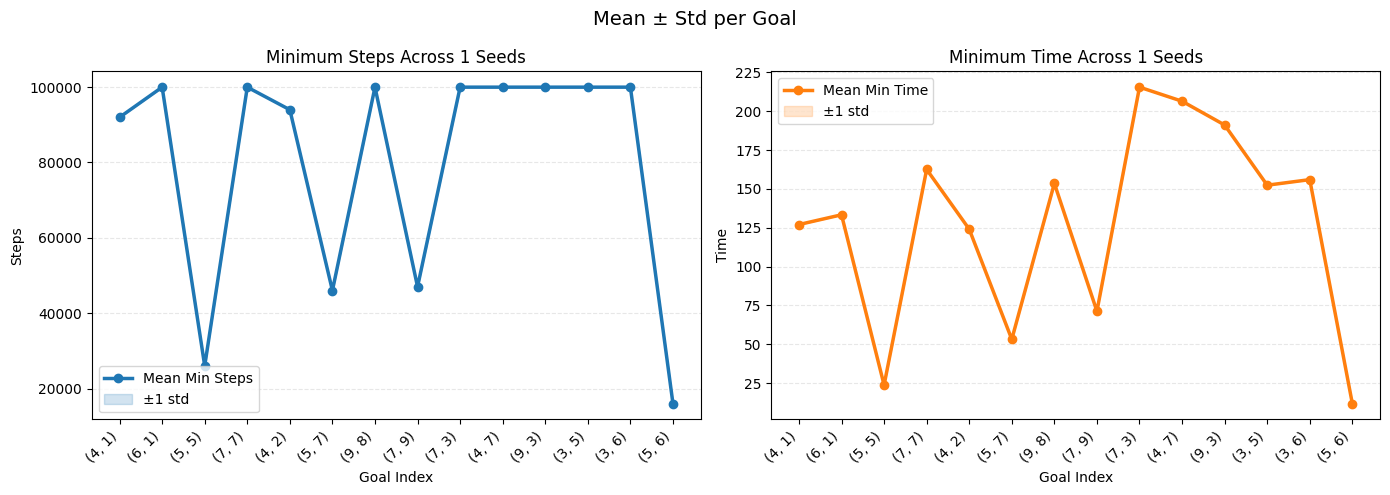

In [20]:
plot_min_steps_and_min_time(overall_results=overall_results_retrain, seeds=SEEDS)

In [21]:
def plot_train_vs_retrain_steps(
    overall_results_train,
    overall_results_retrain,
    seeds=None,
    metric="min_steps",
    title=None,
):
    import numpy as np
    import matplotlib.pyplot as plt

    common_goals = [
        goal for goal in overall_results_train.keys()
        if goal in overall_results_retrain
    ]

    used_goals = []
    train_mean = []
    train_std = []
    retrain_mean = []
    retrain_std = []

    for goal in common_goals:
        train_raw = overall_results_train[goal].get(metric, [])
        retrain_raw = overall_results_retrain[goal].get(metric, [])

        train_arr = np.array(
            [np.nan if x is None else x for x in train_raw],
            dtype=float
        ).flatten()

        retrain_arr = np.array(
            [np.nan if x is None else x for x in retrain_raw],
            dtype=float
        ).flatten()

        if np.all(np.isnan(train_arr)) or np.all(np.isnan(retrain_arr)):
            print(f"[WARN] Skipping goal {goal}: all values missing in train or retrain")
            continue

        used_goals.append(goal)
        train_mean.append(np.nanmean(train_arr))
        train_std.append(np.nanstd(train_arr))
        retrain_mean.append(np.nanmean(retrain_arr))
        retrain_std.append(np.nanstd(retrain_arr))

    if not used_goals:
        raise ValueError("No overlapping goals with valid train/retrain data found.")

    x = np.arange(len(used_goals))
    train_mean = np.array(train_mean)
    train_std = np.array(train_std)
    retrain_mean = np.array(retrain_mean)
    retrain_std = np.array(retrain_std)

    fig, ax = plt.subplots(figsize=(12, 5))

    ax.plot(
        x, train_mean,
        color="tab:blue",
        marker="o",
        linewidth=2.5,
        label="Train"
    )
    ax.fill_between(
        x,
        train_mean - train_std,
        train_mean + train_std,
        color="tab:blue",
        alpha=0.18
    )

    ax.plot(
        x, retrain_mean,
        color="tab:red",
        marker="s",
        linewidth=2.5,
        label="Retrain"
    )
    ax.fill_between(
        x,
        retrain_mean - retrain_std,
        retrain_mean + retrain_std,
        color="tab:red",
        alpha=0.18
    )

    ax.set_xticks(x)
    ax.set_xticklabels([str(g) for g in used_goals], rotation=45, ha="right")
    ax.set_xlabel("Goal")
    ax.set_ylabel("Steps" if metric == "min_steps" else "Time")

    if title is None:
        n_seeds = len(seeds) if seeds is not None else "N"
        metric_name = "Steps" if metric == "min_steps" else "Time"
        title = f"Train vs Retrain {metric_name} Across {n_seeds} Seeds"

    ax.set_title(title)
    ax.grid(True, axis="y", linestyle="--", alpha=0.3)
    ax.legend(loc="best")

    fig.tight_layout()
    plt.show()

plot_train_vs_retrain_steps(
    overall_results_train=overall_results,
    overall_results_retrain=overall_results_retrain,
    seeds=SEEDS,
    metric="min_steps",
    title="Train vs Retrain Minimum Steps"
)

plot_train_vs_retrain_steps(
    overall_results_train=overall_results,
    overall_results_retrain=overall_results_retrain,
    seeds=SEEDS,
    metric="min_time",
    title="Train vs Retrain Minimum Time"
)

ValueError: No overlapping goals with valid train/retrain data found.

## HTML visualisation

In [ ]:
for goal, data in overall_results.items():
    print(goal)
    print("task_embeddings:", len(data.get("task_embeddings", [])))
    print("sa_fixed_probe_embeddings:", len(data.get("sa_fixed_probe_embeddings", [])))
    print("sa_batches_final:", len(data.get("sa_batches_final", [])))

dashboard = plot_full_embedding_dashboard_2d_html(
    overall_results=overall_results,
    qnet=q_network,
    mode="all",
    save_html="plots/full_embedding_dashboard_maze_combined_loss.html",
    weights_his=weight_history,
)

print(dashboard["save_html"])
print(dashboard["isotropy_metrics"])